# Deforestation_tracker_development

In [1]:
import ee
import geemap
import xarray as xr
import numpy as np
from datetime import datetime
import os

import geopandas as gpd
import rioxarray
import dask
import rasterio
from scipy.ndimage import uniform_filter
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

from shapely.geometry import mapping

In [2]:
ee.Authenticate(auth_mode='localhost')
ee.Initialize(project='worldpeatland')

## Orbit test

In [15]:


# Load AOI
ROI_FILE = '/data/LEON/P6_forest_agri_uganda/area/counties_bugoma_cut_4326.gpkg'
gdf = gpd.read_file(ROI_FILE)
if gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs('EPSG:4326')

geom = gdf.unary_union
roi = ee.Geometry.Polygon(list(mapping(geom)['coordinates'][0]))

# Check ALL available orbits for your area
s1_all = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate('2020-01-01', '2025-01-01')
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
    .select(['VH']))

# Get unique orbit numbers
orbits = s1_all.aggregate_array('relativeOrbitNumber_start').distinct().getInfo()
print(f"Available DESCENDING orbits: {sorted(orbits)}")

# Count images per orbit
for orbit in sorted(orbits):
    s1_orbit = s1_all.filter(ee.Filter.eq('relativeOrbitNumber_start', orbit))
    n_images = s1_orbit.size().getInfo()
    print(f"  Orbit {orbit}: {n_images} images")

# Also check ASCENDING
s1_asc = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate('2020-01-01', '2025-01-01')
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
    .select(['VH']))

orbits_asc = s1_asc.aggregate_array('relativeOrbitNumber_start').distinct().getInfo()
print(f"\nAvailable ASCENDING orbits: {sorted(orbits_asc)}")

for orbit in sorted(orbits_asc):
    s1_orbit = s1_asc.filter(ee.Filter.eq('relativeOrbitNumber_start', orbit))
    n_images = s1_orbit.size().getInfo()
    print(f"  Orbit {orbit}: {n_images} images")

/home/gkodl/.conda/envs/s1_defotracker/lib/python3.11/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'counties_bugoma_cut_4326.gpkg': 'counties_bugoma_4326' (default), 'counties_bugoma_cut_4326'. Specify layer parameter to avoid this warning.
  result = read_func(
/tmp/ipykernel_3044321/521831417.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = gdf.unary_union


Available DESCENDING orbits: [21, 123]
  Orbit 21: 302 images
  Orbit 123: 180 images

Available ASCENDING orbits: [101, 102]
  Orbit 101: 152 images
  Orbit 102: 78 images


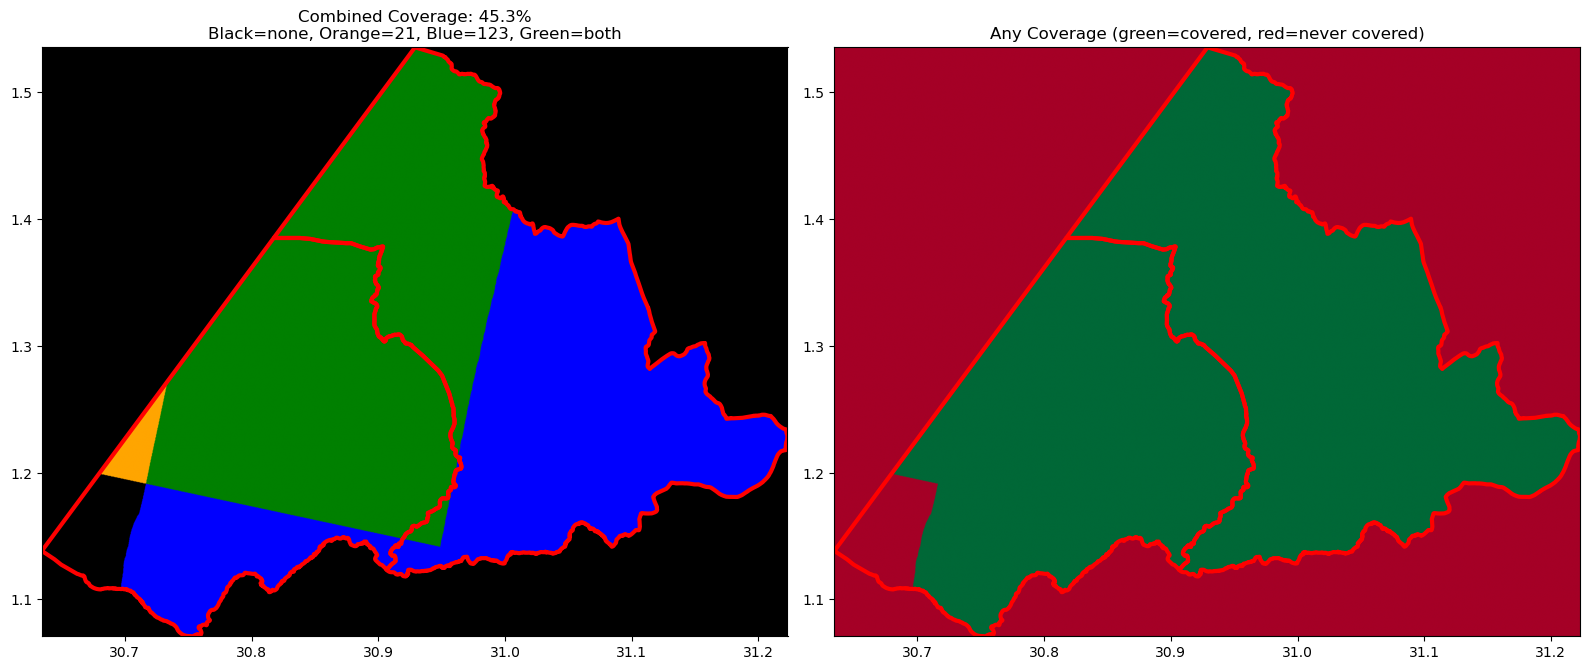

Coverage statistics:
  Orbit 123 only: 20.4%
  Orbit 21 only: 0.6%
  Both orbits: 24.3%
  Neither orbit: 54.7%
  Total covered: 45.3%


In [27]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

ds = xr.open_zarr('/data/LEON/P6_forest_agri_uganda/s1_timeseries/s1_aligned_TEST_dual.zarr')
gdf = gpd.read_file(ROI_FILE, layer='counties_bugoma_cut_4326')

# Create composite showing which orbit covers each pixel
orbit_123_img = ds.VH[:, :, 1].values  # Jan 10 - orbit 123
orbit_21_img = ds.VH[:, :, 2].values   # Jan 21 - orbit 21

# Coverage masks
coverage_123 = ~np.isnan(orbit_123_img) & (orbit_123_img != 0)
coverage_21 = ~np.isnan(orbit_21_img) & (orbit_21_img != 0)

# Combined coverage
coverage_combined = coverage_123 | coverage_21
coverage_pct = coverage_combined.sum() / coverage_combined.size * 100

# Coverage map: 0=no data, 1=orbit 21 only, 2=orbit 123 only, 3=both
coverage_map = np.zeros_like(orbit_123_img)
coverage_map[coverage_21] = 1
coverage_map[coverage_123] = 2
coverage_map[coverage_21 & coverage_123] = 3

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

extent = [ds.x.min().values, ds.x.max().values, ds.y.min().values, ds.y.max().values]

# Combined coverage
from matplotlib.colors import ListedColormap
colors = ['black', 'orange', 'blue', 'green']  # none, 21 only, 123 only, both
cmap = ListedColormap(colors)

im = axes[0].imshow(coverage_map, cmap=cmap, extent=extent, origin='upper')
gdf.boundary.plot(ax=axes[0], color='red', linewidth=3)
axes[0].set_title(f'Combined Coverage: {coverage_pct:.1f}%\nBlack=none, Orange=21, Blue=123, Green=both')

# Show which pixels are never covered
axes[1].imshow(coverage_combined, cmap='RdYlGn', extent=extent, origin='upper')
gdf.boundary.plot(ax=axes[1], color='red', linewidth=3)
axes[1].set_title('Any Coverage (green=covered, red=never covered)')

plt.tight_layout()
plt.savefig('orbit_coverage_analysis.png', dpi=150)
plt.show()

print(f"Coverage statistics:")
print(f"  Orbit 123 only: {np.sum(coverage_123 & ~coverage_21) / coverage_combined.size * 100:.1f}%")
print(f"  Orbit 21 only: {np.sum(coverage_21 & ~coverage_123) / coverage_combined.size * 100:.1f}%")
print(f"  Both orbits: {np.sum(coverage_123 & coverage_21) / coverage_combined.size * 100:.1f}%")
print(f"  Neither orbit: {np.sum(~coverage_combined) / coverage_combined.size * 100:.1f}%")
print(f"  Total covered: {coverage_pct:.1f}%")

Testing ASCENDING orbits (101, 102)...
Found 3 ascending images in January 2020
  Downloaded orbit 101: (1714, 2185)
  Downloaded orbit 101: (1714, 2185)

Coverage comparison:
  DESCENDING (21+123): 45.3%
  ASCENDING (101+102): 46.9%


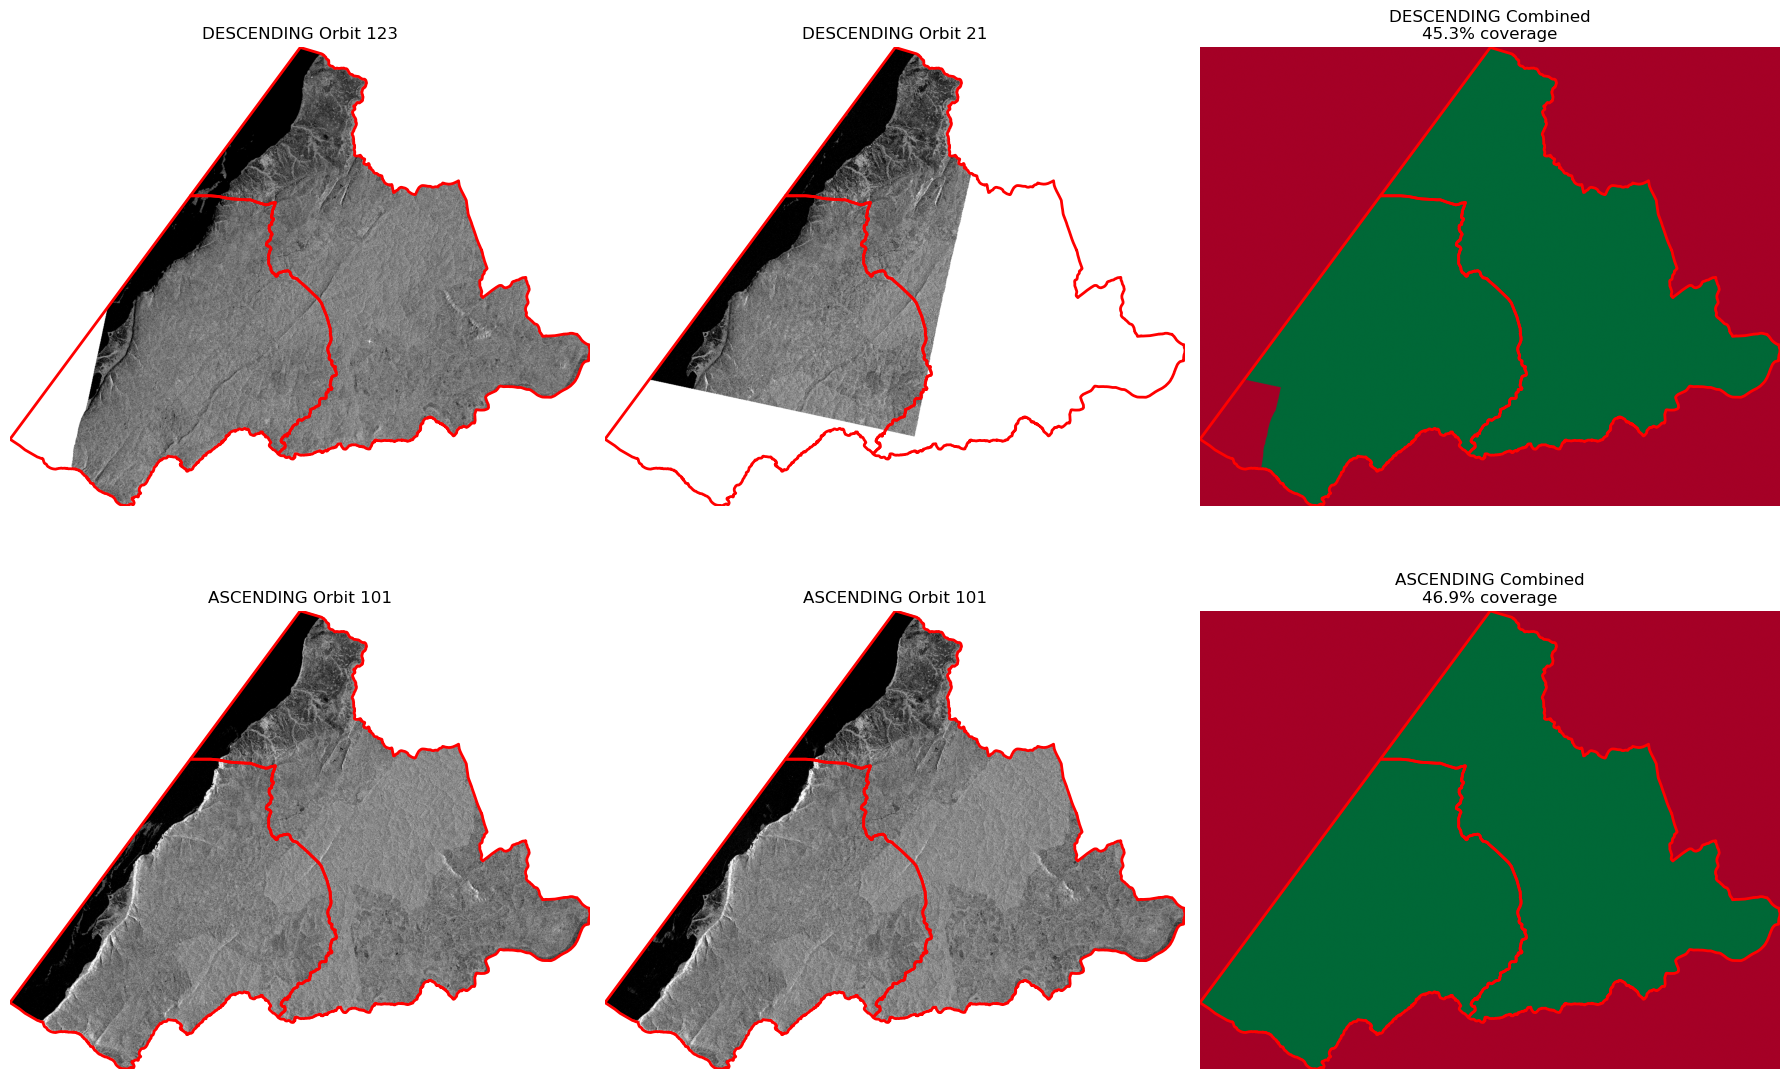


RECOMMENDATION
⚠️ Both have similar coverage (~46.9%)
   Consider using ALL 4 orbits (21+123+101+102)


In [7]:
"""
TEST ASCENDING ORBIT COVERAGE
==============================
Check if ascending orbits provide better coverage
"""


# Load AOI
ROI_FILE = '/data/LEON/P6_forest_agri_uganda/area/counties_bugoma_cut_4326.gpkg'
gdf = gpd.read_file(ROI_FILE, layer='counties_bugoma_cut_4326')
if gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs('EPSG:4326')

geom = gdf.union_all()
roi = ee.Geometry.Polygon(list(mapping(geom)['coordinates'][0]))
bounds = gdf.total_bounds

# Test ASCENDING orbits
ORBITS_ASC = [101, 102]
SCALE = 30

print("Testing ASCENDING orbits (101, 102)...")

s1_asc = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate('2020-01-01', '2020-02-01')  # Just January for quick test
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
    .filter(ee.Filter.inList('relativeOrbitNumber_start', ORBITS_ASC))
    .select(['VH'])
    .map(lambda img: img.clip(roi))
    .sort('system:time_start'))

n_asc = s1_asc.size().getInfo()
print(f"Found {n_asc} ascending images in January 2020")

# Get first image from each orbit
img_list = s1_asc.toList(n_asc)

# Download first 2 images (one from each orbit likely)
images_asc = []
for i in range(min(2, n_asc)):
    img = ee.Image(img_list.get(i))
    orbit = img.get('relativeOrbitNumber_start').getInfo()
    projection = img.select('VH').projection()
    
    vh = geemap.ee_to_numpy(
        img.select('VH').reproject(crs=projection, scale=SCALE),
        region=roi, scale=SCALE
    )
    if len(vh.shape) == 3:
        vh = vh[:, :, 0]
    
    # Flip vertically
    vh = np.flip(vh, axis=0)
    
    images_asc.append({'data': vh, 'orbit': orbit})
    print(f"  Downloaded orbit {orbit}: {vh.shape}")

# Compare with descending (load from saved test)
import xarray as xr
ds_desc = xr.open_zarr('/data/LEON/P6_forest_agri_uganda/s1_timeseries/s1_aligned_TEST_dual.zarr')
orbit_123 = ds_desc.VH[:, :, 1].values
orbit_21 = ds_desc.VH[:, :, 2].values

# Coverage analysis
coverage_desc_123 = ~np.isnan(orbit_123) & (orbit_123 != 0)
coverage_desc_21 = ~np.isnan(orbit_21) & (orbit_21 != 0)
coverage_desc = coverage_desc_123 | coverage_desc_21

if len(images_asc) >= 2:
    coverage_asc_1 = ~np.isnan(images_asc[0]['data']) & (images_asc[0]['data'] != 0)
    coverage_asc_2 = ~np.isnan(images_asc[1]['data']) & (images_asc[1]['data'] != 0)
    coverage_asc = coverage_asc_1 | coverage_asc_2
    
    # Statistics
    coverage_desc_pct = coverage_desc.sum() / coverage_desc.size * 100
    coverage_asc_pct = coverage_asc.sum() / coverage_asc.size * 100
    
    print(f"\nCoverage comparison:")
    print(f"  DESCENDING (21+123): {coverage_desc_pct:.1f}%")
    print(f"  ASCENDING (101+102): {coverage_asc_pct:.1f}%")
    
    # Visualize
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    extent = [ds_desc.x.min().values, ds_desc.x.max().values, 
              ds_desc.y.min().values, ds_desc.y.max().values]
    
    # Row 1: Descending orbits
    axes[0, 0].imshow(orbit_123, cmap='gray', vmin=-25, vmax=-5, extent=extent, origin='upper')
    gdf.boundary.plot(ax=axes[0, 0], color='red', linewidth=2)
    axes[0, 0].set_title('DESCENDING Orbit 123')
    
    axes[0, 1].imshow(orbit_21, cmap='gray', vmin=-25, vmax=-5, extent=extent, origin='upper')
    gdf.boundary.plot(ax=axes[0, 1], color='red', linewidth=2)
    axes[0, 1].set_title('DESCENDING Orbit 21')
    
    axes[0, 2].imshow(coverage_desc, cmap='RdYlGn', extent=extent, origin='upper')
    gdf.boundary.plot(ax=axes[0, 2], color='red', linewidth=2)
    axes[0, 2].set_title(f'DESCENDING Combined\n{coverage_desc_pct:.1f}% coverage')
    
    # Row 2: Ascending orbits
    axes[1, 0].imshow(images_asc[0]['data'], cmap='gray', vmin=-25, vmax=-5, extent=extent, origin='upper')
    gdf.boundary.plot(ax=axes[1, 0], color='red', linewidth=2)
    axes[1, 0].set_title(f"ASCENDING Orbit {images_asc[0]['orbit']}")
    
    axes[1, 1].imshow(images_asc[1]['data'], cmap='gray', vmin=-25, vmax=-5, extent=extent, origin='upper')
    gdf.boundary.plot(ax=axes[1, 1], color='red', linewidth=2)
    axes[1, 1].set_title(f"ASCENDING Orbit {images_asc[1]['orbit']}")
    
    axes[1, 2].imshow(coverage_asc, cmap='RdYlGn', extent=extent, origin='upper')
    gdf.boundary.plot(ax=axes[1, 2], color='red', linewidth=2)
    axes[1, 2].set_title(f'ASCENDING Combined\n{coverage_asc_pct:.1f}% coverage')
    
    for ax in axes.flat:
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('descending_vs_ascending_coverage.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Recommendation
    print("\n" + "="*60)
    print("RECOMMENDATION")
    print("="*60)
    if coverage_asc_pct > coverage_desc_pct + 10:
        print(f"✅ Use ASCENDING orbits (101+102) - {coverage_asc_pct:.1f}% coverage")
    elif coverage_desc_pct > coverage_asc_pct + 10:
        print(f"✅ Use DESCENDING orbits (21+123) - {coverage_desc_pct:.1f}% coverage")
    else:
        print(f"⚠️ Both have similar coverage (~{max(coverage_asc_pct, coverage_desc_pct):.1f}%)")
        print("   Consider using ALL 4 orbits (21+123+101+102)")

else:
    print("⚠️ Not enough ascending images for comparison")

In [11]:
"""
S1 DOWNLOAD - SINGLE ORBIT 101 (ASCENDING)
===========================================
"""

# ===================== CONFIG =====================
ROI_FILE = '/data/LEON/P6_forest_agri_uganda/area/counties_bugoma_cut_4326.gpkg'
OUTPUT_DIR = '/data/LEON/P6_forest_agri_uganda/s1_timeseries'
SCALE = 30
ORBIT = 101  

TEST_MODE = True
N_TEST_IMAGES = 2

# ===================== LOAD ROI =====================
gdf = gpd.read_file(ROI_FILE, layer='counties_bugoma_cut_4326')
if gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs('EPSG:4326')

geom = gdf.union_all()
roi = ee.Geometry.Polygon(list(mapping(geom)['coordinates'][0]))
bounds = gdf.total_bounds

print(f"ROI bounds: {bounds}")

# ===================== GET S1 COLLECTION (ORBIT 101 ONLY) =====================
s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate('2020-01-01', '2025-01-01')
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
    .filter(ee.Filter.eq('relativeOrbitNumber_start', ORBIT))
    .select(['VH'])
    .map(lambda img: img.clip(roi))
    .sort('system:time_start'))

n_total = s1.size().getInfo()
dates_all = [np.datetime64(datetime.fromtimestamp(d/1000)) 
             for d in s1.aggregate_array('system:time_start').getInfo()]

print(f"\nOrbit {ORBIT} (ASCENDING)")
print(f"Total images: {n_total}")

if TEST_MODE:
    n_images = N_TEST_IMAGES
    dates = dates_all[:n_images]
    print(f"\n🧪 TEST MODE: Downloading {n_images}/{n_total} images")
else:
    n_images = n_total
    dates = dates_all
    print(f"\nDownloading all {n_images} images")

print(f"Date range: {dates[0]} to {dates[-1]}")

# ===================== DOWNLOAD =====================
img_list = s1.toList(n_total)
first_img = ee.Image(img_list.get(0))
projection = first_img.select('VH').projection()

vh_first = geemap.ee_to_numpy(
    first_img.select('VH').reproject(crs=projection, scale=SCALE),
    region=roi, scale=SCALE
)
if len(vh_first.shape) == 3:
    vh_first = vh_first[:, :, 0]

ny, nx = vh_first.shape
print(f"Grid: {ny}×{nx} pixels")

all_data = np.zeros((ny, nx, n_images), dtype=np.float32)
all_data[:, :, 0] = vh_first

for i in range(1, n_images):
    print(f"  Downloading image {i+1}/{n_images}")
    
    try:
        img = ee.Image(img_list.get(i))
        vh = geemap.ee_to_numpy(
            img.select('VH').reproject(crs=projection, scale=SCALE),
            region=roi, scale=SCALE
        )
        if len(vh.shape) == 3:
            vh = vh[:, :, 0]
        all_data[:, :, i] = vh if vh.shape == (ny, nx) else np.nan
    except Exception as e:
        print(f"    Error: {e}")
        all_data[:, :, i] = np.nan

# ===================== APPLY VERTICAL FLIP =====================
print("\n⚠ Applying vertical flip...")
all_data = np.flip(all_data, axis=0)

# ===================== SAVE =====================
os.makedirs(OUTPUT_DIR, exist_ok=True)

lons = np.linspace(bounds[0], bounds[2], nx)
lats = np.linspace(bounds[3], bounds[1], ny)

ds = xr.Dataset(
    {'VH': (['y', 'x', 'time'], all_data)},
    coords={'x': lons, 'y': lats, 'time': dates},
    attrs={'orbit': ORBIT, 'pass_direction': 'ASCENDING'}  # ← Fixed!
)

suffix = f"_TEST_orbit{ORBIT}" if TEST_MODE else f"_orbit{ORBIT}"  # ← Fixed!
output_file = f"{OUTPUT_DIR}/s1_aligned{suffix}.zarr"

ds.to_zarr(output_file, mode='w', encoding={'VH': {'chunks': (ny, nx, min(50, n_images))}})

print(f"\n✓ Saved: {output_file}")
print(f"  Shape: {all_data.shape}")
print(f"  Coverage: {np.sum(~np.isnan(all_data) & (all_data != 0)) / all_data.size * 100:.1f}%")

if TEST_MODE:
    print(f"\n✅ Test successful! Check coverage with orbit 101.")
    print(f"   If coverage >80%, set TEST_MODE = False for full download!")

ROI bounds: [30.63444328  1.07092791 31.22295212  1.53564323]

Orbit 101 (ASCENDING)
Total images: 152

🧪 TEST MODE: Downloading 2/152 images
Date range: 2020-01-02T16:13:18.000000 to 2020-01-14T16:13:18.000000
Grid: 1714×2185 pixels

⚠ Applying vertical flip...

✓ Saved: /data/LEON/P6_forest_agri_uganda/s1_timeseries/s1_aligned_TEST_orbit101.zarr
  Shape: (1714, 2185, 2)
  Coverage: 46.9%

✅ Test successful! Check coverage with orbit 101.
   If coverage >80%, set TEST_MODE = False for full download!


/home/gkodl/.conda/envs/s1_defotracker/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## Download S1 from GEE locally

In [3]:
"""
S1 DOWNLOAD complete time series - ORBIT 101 (ASCENDING)
===========================================================
"""

# ===================== CONFIG =====================
ROI_FILE = '/data/LEON/P6_forest_agri_uganda/area/counties_bugoma_cut_4326.gpkg'
OUTPUT_DIR = '/data/LEON/P6_forest_agri_uganda/s1_timeseries'
SCALE = 30
ORBIT = 101

# ===================== LOAD ROI =====================
gdf = gpd.read_file(ROI_FILE, layer='counties_bugoma_cut_4326')
if gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs('EPSG:4326')

geom = gdf.union_all()
roi = ee.Geometry.Polygon(list(mapping(geom)['coordinates'][0]))
bounds = gdf.total_bounds

# ===================== GET S1 COLLECTION =====================
s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate('2020-01-01', '2025-01-01')
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
    .filter(ee.Filter.eq('relativeOrbitNumber_start', ORBIT))
    .select(['VH'])
    .map(lambda img: img.clip(roi))
    .sort('system:time_start'))

n_images = s1.size().getInfo()
dates = [np.datetime64(datetime.fromtimestamp(d/1000)) 
         for d in s1.aggregate_array('system:time_start').getInfo()]

print(f"Downloading {n_images} images from orbit {ORBIT} (ASCENDING)")
print(f"Date range: {dates[0]} to {dates[-1]}")

# ===================== DOWNLOAD =====================
img_list = s1.toList(n_images)
first_img = ee.Image(img_list.get(0))
projection = first_img.select('VH').projection()

vh_first = geemap.ee_to_numpy(
    first_img.select('VH').reproject(crs=projection, scale=SCALE),
    region=roi, scale=SCALE
)
if len(vh_first.shape) == 3:
    vh_first = vh_first[:, :, 0]

ny, nx = vh_first.shape
print(f"Grid: {ny}×{nx} pixels")

all_data = np.zeros((ny, nx, n_images), dtype=np.float32)
all_data[:, :, 0] = vh_first

for i in range(1, n_images):
    if i % 10 == 0:
        print(f"  Progress: {i}/{n_images}")
    
    try:
        img = ee.Image(img_list.get(i))
        vh = geemap.ee_to_numpy(
            img.select('VH').reproject(crs=projection, scale=SCALE),
            region=roi, scale=SCALE
        )
        if len(vh.shape) == 3:
            vh = vh[:, :, 0]
        all_data[:, :, i] = vh if vh.shape == (ny, nx) else np.nan
    except:
        all_data[:, :, i] = np.nan

# Flip vertically for standard raster orientation
all_data = np.flip(all_data, axis=0)

# ===================== SAVE =====================
os.makedirs(OUTPUT_DIR, exist_ok=True)

lons = np.linspace(bounds[0], bounds[2], nx)
lats = np.linspace(bounds[3], bounds[1], ny)

ds = xr.Dataset(
    {'VH': (['y', 'x', 'time'], all_data)},
    coords={'x': lons, 'y': lats, 'time': dates},
    attrs={'orbit': ORBIT, 'pass_direction': 'ASCENDING', 'scale': SCALE}
)

output_file = f"{OUTPUT_DIR}/s1_orbit101.zarr"
ds.to_zarr(output_file, mode='w', encoding={'VH': {'chunks': (ny, nx, 50)}})

print(f"\n✓ Saved: {output_file}")
print(f"  Shape: {all_data.shape}")
print(f"  Coverage: {np.sum(~np.isnan(all_data) & (all_data != 0)) / all_data.size * 100:.1f}%")
print("\n Download complete! Ready for filtering and analysis.")

Date range: 2020-01-02T16:13:18.000000 to 2024-12-30T16:13:34.000000
Grid: 1714×2185 pixels
  Progress: 10/152
  Progress: 20/152
  Progress: 30/152
  Progress: 40/152
  Progress: 50/152
  Progress: 60/152
  Progress: 70/152
  Progress: 80/152
  Progress: 90/152
  Progress: 100/152
  Progress: 110/152
  Progress: 120/152
  Progress: 130/152
  Progress: 140/152
  Progress: 150/152


/home/gkodl/.conda/envs/s1_defotracker/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(



✓ Saved: /data/LEON/P6_forest_agri_uganda/s1_timeseries/s1_orbit101.zarr
  Shape: (1714, 2185, 152)
  Coverage: 46.4%

 Download complete! Ready for filtering and analysis.


## Load Zarr

In [8]:
ds = xr.open_zarr('/data/LEON/P6_forest_agri_uganda/s1_timeseries/s1_orbit101.zarr')
ds

<xarray.Dataset> Size: 2GB
Dimensions:  (y: 1714, x: 2185, time: 152)
Coordinates:
  * y        (y) float64 14kB 1.536 1.535 1.535 1.535 ... 1.071 1.071 1.071
  * x        (x) float64 17kB 30.63 30.63 30.63 30.64 ... 31.22 31.22 31.22
  * time     (time) datetime64[ns] 1kB 2020-01-02T16:13:18 ... 2024-12-30T16:...
Data variables:
    VH       (y, x, time) float32 2GB dask.array<chunksize=(1714, 2185, 50), meta=np.ndarray>
Attributes:
    orbit:           101
    pass_direction:  ASCENDING
    scale:           30

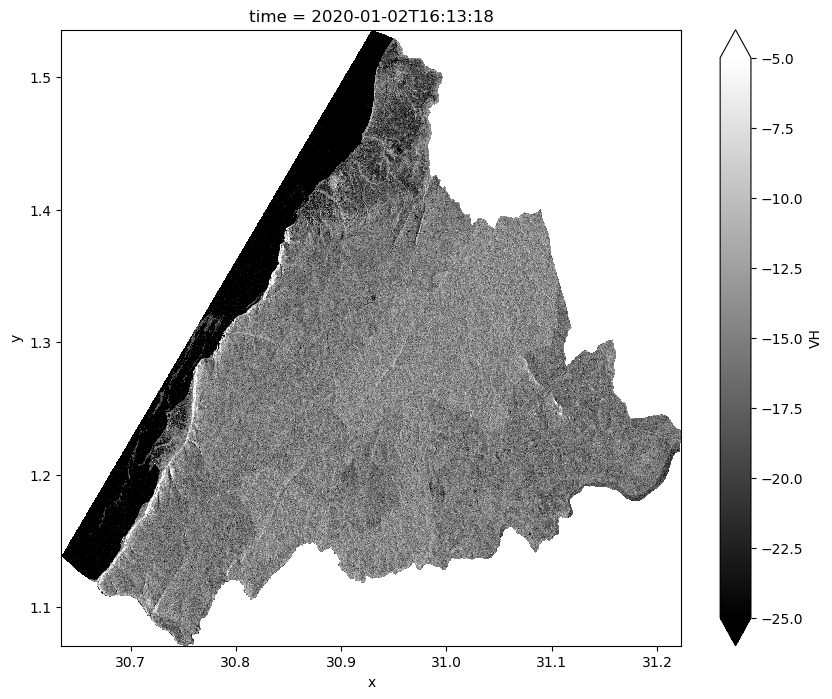

In [10]:
ds.VH.isel(time=0).plot(cmap='gray', vmin=-25, vmax=-5, figsize=(10, 8))

<Axes: title={'center': 'time = 2020-01-02T16:13:18'}, xlabel='x', ylabel='y'>

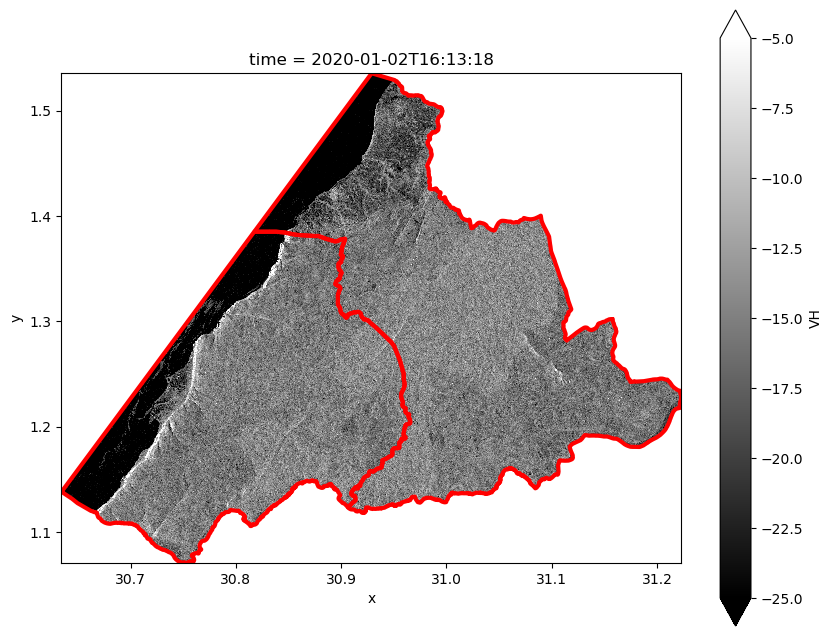

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
ds.VH.isel(time=0).plot(ax=ax, cmap='gray', vmin=-25, vmax=-5)
gdf.to_crs("EPSG:4326").boundary.plot(ax=ax, color='red', linewidth=3)

In [9]:

ds = ds.transpose("time", "y", "x")
ds = ds.rio.write_crs("EPSG:4326")
ds_utm = ds.rio.reproject("EPSG:32636")

ds_utm.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 36N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",33],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32636"]]')

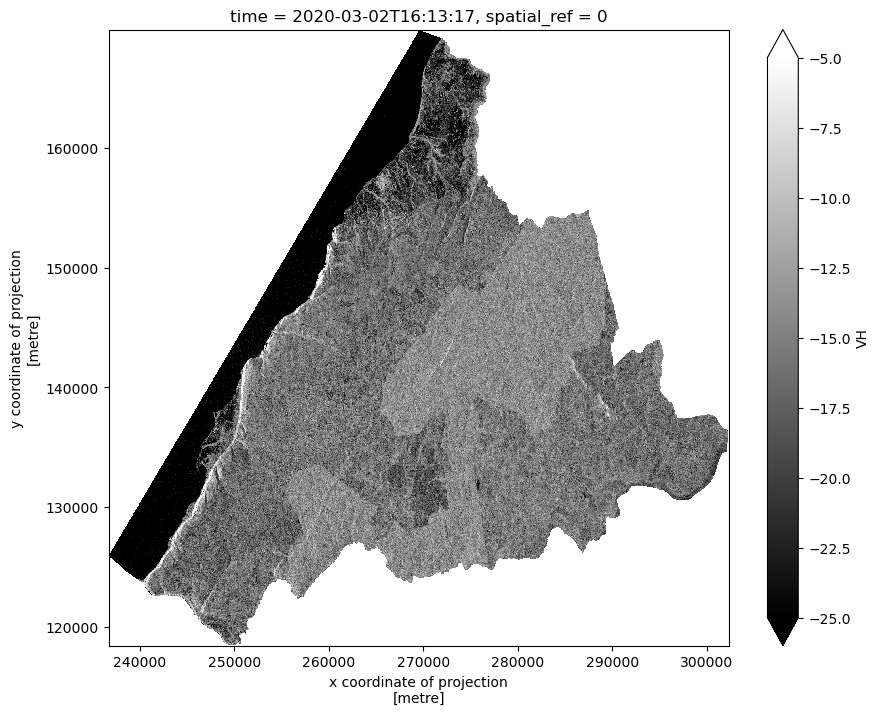

In [10]:
ds_utm.VH.isel(time=5).plot(cmap='gray', vmin=-25, vmax=-5, figsize=(10, 8))

In [11]:
# write zarr reprojected
ds_utm.to_zarr("/data/LEON/P6_forest_agri_uganda/s1_timeseries/s1_orbit101_32636.zarr", mode="w", consolidated=True)


/home/gkodl/.conda/envs/s1_defotracker/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## Workflow

## Load Data

In [ ]:
"""
COMPLETE LOCAL PROCESSING WORKFLOW
===================================
Apply forest mask, filters, and logistic fitting
"""


# ===================== LOAD DATA =====================
print("Loading complete time series...")
zarr_complete = "/data/LEON/P6_forest_agri_uganda/s1_timeseries/s1_orbit101_32636.zarr"
ds = xr.open_zarr(zarr_complete)

print(f"Dataset: {ds.dims}")
print(f"Date range: {ds.time[0].values} to {ds.time[-1].values}")

vh_array = ds['VH'].values 
print(f"VH shape: {vh_array.shape}")

# ===================== LOAD AND APPLY FOREST MASK =====================
print("\nLoading forest mask...")
forest_mask_path = "/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2020.tif"

with rasterio.open(forest_mask_path) as src:
    forest_array = src.read(1)
    forest_transform = src.transform
    forest_crs = src.crs

print(f"Forest mask shape: {forest_array.shape}")
print(f"Forest pixels: {(forest_array == 1).sum():,}")

# Resample forest mask to match S1 grid
from scipy.ndimage import zoom

if forest_array.shape != vh_array.shape[:2]:
    print(f"Resampling forest mask from {forest_array.shape} to {vh_array.shape[:2]}...")
    zoom_factors = (vh_array.shape[0] / forest_array.shape[0], 
                    vh_array.shape[1] / forest_array.shape[1])
    forest_resampled = zoom(forest_array, zoom_factors, order=0)  # Nearest neighbor
else:
    forest_resampled = forest_array

print(f"Resampled forest mask: {forest_resampled.shape}")
print(f"Forest pixels in S1 grid: {(forest_resampled == 1).sum():,}")

# Apply mask to data (set non-forest to NaN)
vh_masked = vh_array.copy()
vh_masked[forest_resampled != 1, :] = np.nan

print(f"✓ Forest mask applied")

Loading complete time series...
Dataset: FrozenMappingWarningOnValuesAccess({'y': 1714, 'x': 2185, 'time': 152})
Date range: 2020-01-02T16:13:18.000000000 to 2024-12-30T16:13:34.000000000
VH shape: (1714, 2185, 152)

Loading forest mask...


RasterioIOError: /home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2020.tif: No such file or directory

## Speckle filter

In [ ]:
"""
COMPLETE FILTERING PIPELINE - SIMPLE AND CLEAN
===============================================
1. Load S1 data
2. Apply Lee filter (7x7, radius 3.0)
3. Apply Quegan & Yu multitemporal (5 images)
4. Save filtered result
"""

import xarray as xr
import numpy as np
from scipy.ndimage import convolve

# ===================== 1. LOAD DATA =====================
print("=" * 60)
print("STEP 1: LOADING DATA")
print("=" * 60)

nc_complete = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_aligned.nc"
ds = xr.open_dataset(nc_complete)

vh_array = ds['VH'].values
print(f"Loaded: {vh_array.shape}")
print(f"Date range: {ds.time[0].values} to {ds.time[-1].values}")
print(f"Valid pixels: {np.sum(~np.isnan(vh_array) & (vh_array != 0)):,}")

# ===================== 2. LEE FILTER (7x7) =====================
print("\n" + "=" * 60)
print("STEP 2: APPLYING LEE FILTER (7x7, radius 3.0)")
print("=" * 60)

def create_circular_kernel(radius=3.0):
    """Create circular kernel matching GEE focal_mean"""
    size = int(radius * 2 + 1)
    center = radius
    y, x = np.ogrid[-center:size-center, -center:size-center]
    mask = x**2 + y**2 <= radius**2
    return mask.astype(float)

def circular_mean(image, radius=3.0):
    """Calculate mean with circular kernel"""
    kernel = create_circular_kernel(radius)
    kernel = kernel / kernel.sum()
    return convolve(image, kernel, mode='reflect')

def lee_filter(data, radius=3.0):
    """
    Lee Filter (Lee, 1981)
    Reference: Lee, J.-S. (1981). Computer Graphics and Image Processing, 15, 380-389
    """
    cu_squared = 0.25  # For 4-look GRD
    filtered = np.zeros_like(data)
    
    for t in range(data.shape[2]):
        if t % 20 == 0:
            print(f"  Processing {t+1}/{data.shape[2]}...")
        
        img = data[:, :, t]
        
        # Local mean (circular window)
        mean = circular_mean(img, radius=radius)
        
        # Local variance: Var = E[X²] - E[X]²
        sqr_mean = circular_mean(img**2, radius=radius)
        variance = sqr_mean - mean**2
        variance = np.maximum(variance, 0)
        
        # Lee weight: W = (C_i² - C_u²) / C_i²
        ci_squared = variance / (mean**2 + 1e-10)
        w = np.clip((ci_squared - cu_squared) / (ci_squared + 1e-10), 0, 1)
        
        # Filtered output: I_filtered = μ + W × (I - μ)
        filtered[:, :, t] = mean + w * (img - mean)
    
    return filtered

vh_lee = lee_filter(vh_array, radius=3.0)
print("✓ Lee filter complete!")

# ===================== 3. QUEGAN & YU MULTITEMPORAL =====================
print("\n" + "=" * 60)
print("STEP 3: APPLYING QUEGAN & YU MULTITEMPORAL FILTER (5 images)")
print("=" * 60)

def quegan_yu_multitemporal(data, spatial_radius=3.0, temporal_window=5):
    """
    Quegan & Yu multitemporal filter
    For each time t: uses [t-2, t-1, t, t+1, t+2]
    Formula: Σ(I/μ) / Σ(1/μ)
    """
    ny, nx, nt = data.shape
    filtered = np.zeros_like(data)
    half_window = temporal_window // 2
    
    for t in range(nt):
        if t % 20 == 0:
            print(f"  Processing {t+1}/{nt}...")
        
        # Temporal window
        t_start = max(0, t - half_window)
        t_end = min(nt, t + half_window + 1)
        
        # Accumulators
        sum_norm = np.zeros((ny, nx))
        sum_inv = np.zeros((ny, nx))
        
        # Sum over temporal window
        for tt in range(t_start, t_end):
            img = data[:, :, tt]
            
            # Local spatial mean
            local_mean = circular_mean(img, radius=spatial_radius)
            
            # Normalize and accumulate
            sum_norm = np.nansum([sum_norm, img / (local_mean + 1e-10)], axis=0)
            sum_inv = np.nansum([sum_inv, 1.0 / (local_mean + 1e-10)], axis=0)
        
        # Final result: Σ(I/μ) / Σ(1/μ)
        filtered[:, :, t] = sum_norm / (sum_inv + 1e-10)
    
    return filtered

vh_filtered = quegan_yu_multitemporal(vh_lee, spatial_radius=3.0, temporal_window=5)
print("✓ Quegan & Yu filter complete!")

# ===================== 4. SAVE RESULT =====================
print("\n" + "=" * 60)
print("STEP 4: SAVING FILTERED DATA")
print("=" * 60)

# Create output dataset
ds_filtered = xr.Dataset(
    data_vars={
        'VH_filtered': (['y', 'x', 'time'], vh_filtered),
        'VH_lee': (['y', 'x', 'time'], vh_lee),
        'VH_raw': (['y', 'x', 'time'], vh_array),
    },
    coords={
        'x': ds.x,
        'y': ds.y,
        'time': ds.time,
    },
    attrs={
        'description': 'Filtered S1 time series',
        'filters': 'Lee (7x7, r=3.0) + Quegan & Yu multitemporal (5 images)',
        'lee_reference': 'Lee, J.-S. (1981). Computer Graphics and Image Processing, 15, 380-389',
        'temporal_window': 5,
        'spatial_radius': 3.0,
    }
)

output_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered_w5.nc"

encoding = {
    'VH_filtered': {'zlib': True, 'complevel': 5},
    'VH_lee': {'zlib': True, 'complevel': 5},
    'VH_raw': {'zlib': True, 'complevel': 5},
}

ds_filtered.to_netcdf(output_file, encoding=encoding)

print(f"✓ Saved to: {output_file}")

# ===================== SUMMARY =====================
print("\n" + "=" * 60)
print("FILTERING COMPLETE!")
print("=" * 60)
print("Applied filters:")
print("  1. Lee filter (Lee, 1981)")
print("     - Circular window: radius 3.0 (7×7)")
print("     - Reduces speckle noise")
print()
print("  2. Quegan & Yu multitemporal filter")
print("     - Temporal window: 5 images (t-2, t-1, t, t+1, t+2)")
print("     - Spatial window: 7×7 (radius 3.0)")
print("     - Reduces temporal noise")
print()
print(f"Output saved to: {output_file}")
print("\nReady for deforestation analysis!")

STEP 1: LOADING DATA
Loaded: (480, 712, 179)
Date range: 2020-01-04T03:36:10.000000000 to 2024-12-20T03:36:28.000000000
Valid pixels: 61,114,180

STEP 2: APPLYING LEE FILTER (7x7, radius 3.0)
  Processing 1/179...
  Processing 21/179...
  Processing 41/179...
  Processing 61/179...
  Processing 81/179...
  Processing 101/179...
  Processing 121/179...
  Processing 141/179...
  Processing 161/179...
✓ Lee filter complete!

STEP 3: APPLYING QUEGAN & YU MULTITEMPORAL FILTER (5 images)
  Processing 1/179...
  Processing 21/179...
  Processing 41/179...
  Processing 61/179...
  Processing 81/179...
  Processing 101/179...
  Processing 121/179...
  Processing 141/179...
  Processing 161/179...
✓ Quegan & Yu filter complete!

STEP 4: SAVING FILTERED DATA
✓ Saved to: /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered_w5.nc

FILTERING COMPLETE!
Applied filters:
  1. Lee filter (Lee, 1981)
     - Circular window: radius 3.0 (7×7)
     - Reduces speckle noise

  2. Quegan & Yu 

Loading filtered data...
Timestamp: 2021-11-18T03:36:24.000000000


/tmp/ipykernel_21260/1585344642.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


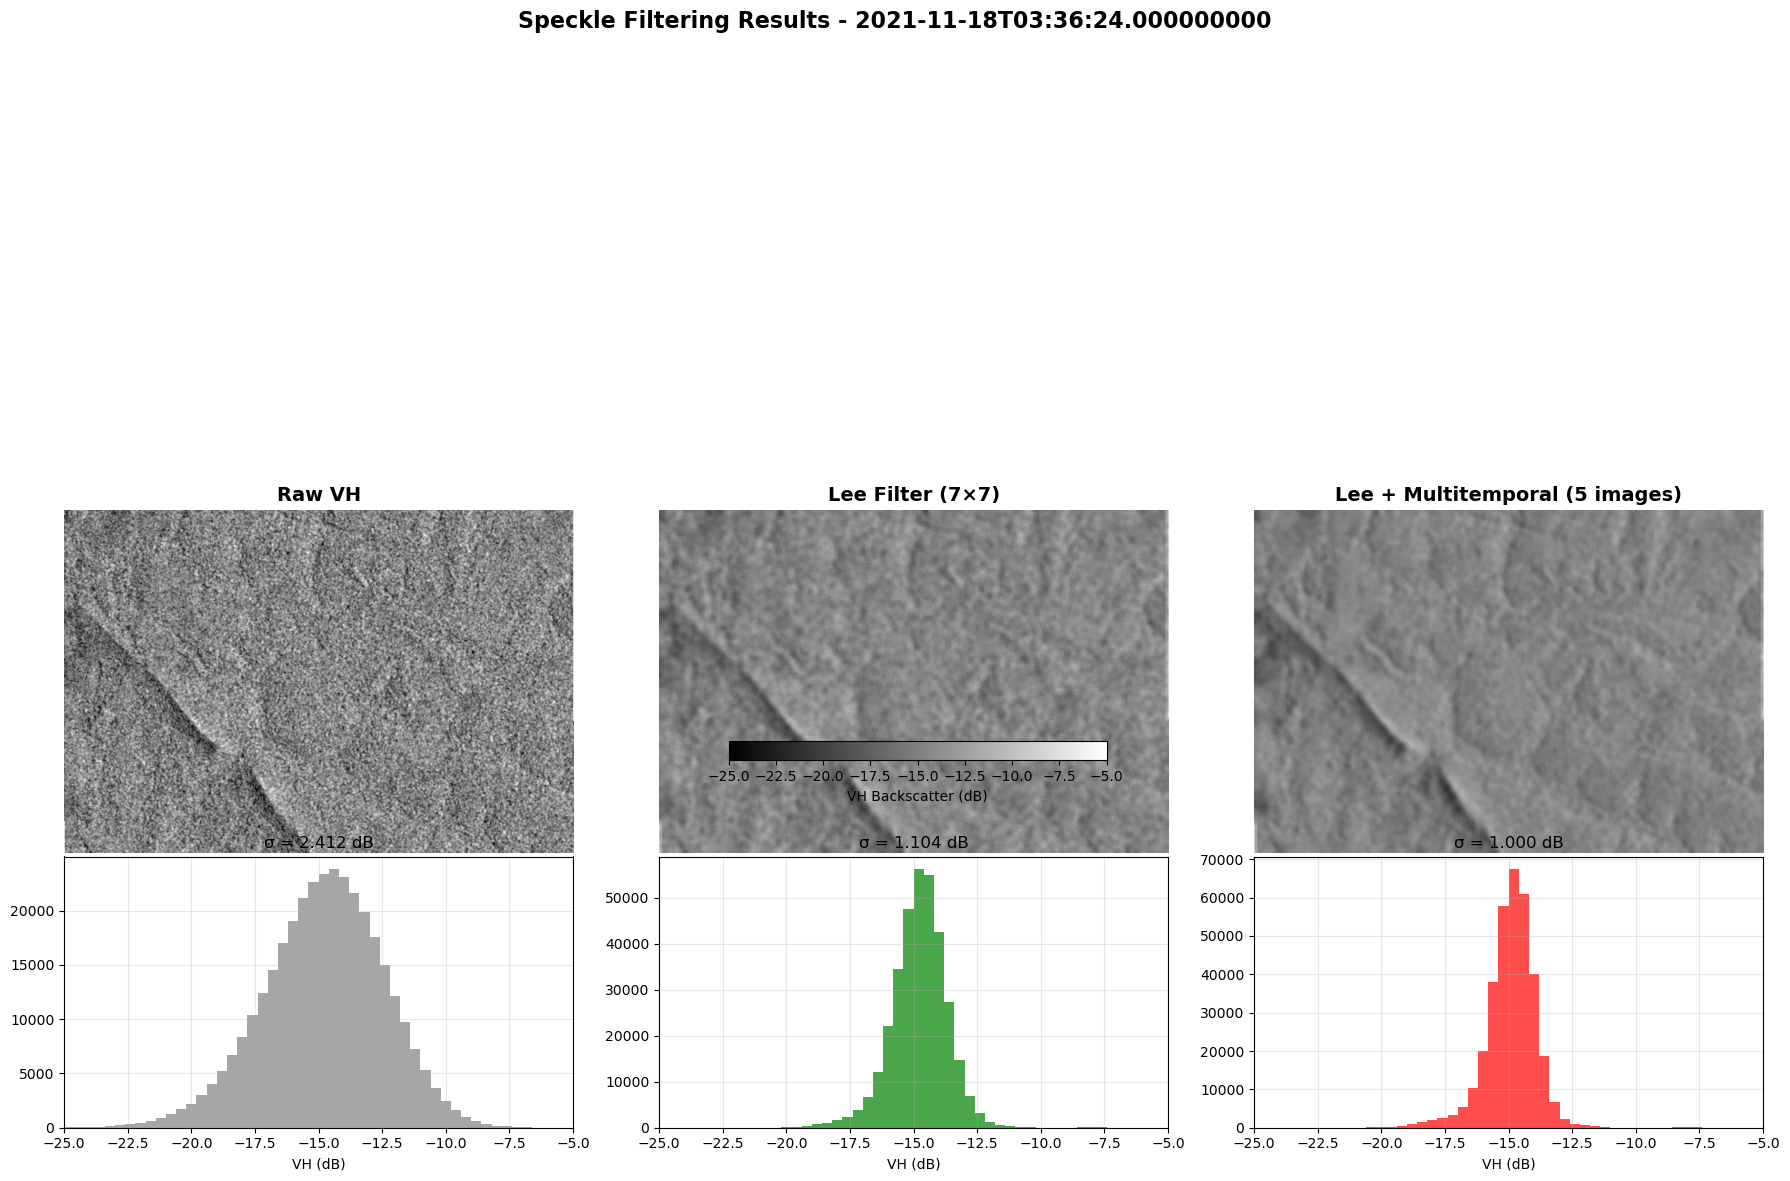


📊 SPECKLE REDUCTION (lower σ = better)
  Raw:            σ = 2.412 dB
  Lee Filter:     σ = 1.104 dB  (54.2% reduction)
  Multitemporal:  σ = 1.000 dB  (58.5% reduction)

✓ Filters successfully reduced speckle noise!


In [29]:
"""
VISUALIZE FILTERING RESULTS - SIMPLIFIED
=========================================
No gap filling needed with dense data!
"""

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ===================== LOAD FILTERED DATA =====================
print("Loading filtered data...")
filtered_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered_w5.nc"
ds = xr.open_dataset(filtered_file)

# Pick a middle timestamp
t = 87  # Mid 2021

vh_raw = ds['VH_raw'][:, :, t].values
vh_lee = ds['VH_lee'][:, :, t].values
vh_filtered = ds['VH_filtered'][:, :, t].values

print(f"Timestamp: {ds.time[t].values}")

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 3, figsize=(18, 12), 
                         gridspec_kw={'height_ratios': [3, 1]})

vmin, vmax = -25, -5

# Top row: Images
axes[0, 0].imshow(vh_raw, cmap='gray', vmin=vmin, vmax=vmax)
axes[0, 0].set_title('Raw VH', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(vh_lee, cmap='gray', vmin=vmin, vmax=vmax)
axes[0, 1].set_title('Lee Filter (7×7)', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(vh_filtered, cmap='gray', vmin=vmin, vmax=vmax)
axes[0, 2].set_title('Lee + Multitemporal (5 images)', fontsize=14, fontweight='bold')
axes[0, 2].axis('off')

# Bottom row: Histograms
axes[1, 0].hist(vh_raw.flatten(), bins=50, color='gray', alpha=0.7, range=(vmin, vmax))
axes[1, 0].set_xlabel('VH (dB)')
axes[1, 0].set_xlim(vmin, vmax)
axes[1, 0].set_title(f'σ = {np.nanstd(vh_raw):.3f} dB', fontsize=12)
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(vh_lee.flatten(), bins=50, color='green', alpha=0.7, range=(vmin, vmax))
axes[1, 1].set_xlabel('VH (dB)')
axes[1, 1].set_xlim(vmin, vmax)
axes[1, 1].set_title(f'σ = {np.nanstd(vh_lee):.3f} dB', fontsize=12)
axes[1, 1].grid(alpha=0.3)

axes[1, 2].hist(vh_filtered.flatten(), bins=50, color='red', alpha=0.7, range=(vmin, vmax))
axes[1, 2].set_xlabel('VH (dB)')
axes[1, 2].set_xlim(vmin, vmax)
axes[1, 2].set_title(f'σ = {np.nanstd(vh_filtered):.3f} dB', fontsize=12)
axes[1, 2].grid(alpha=0.3)

# Add colorbar
fig.colorbar(axes[0, 2].images[0], ax=axes[0, :], orientation='horizontal', 
             label='VH Backscatter (dB)', pad=0.02, fraction=0.03)

plt.suptitle(f'Speckle Filtering Results - {ds.time[t].values}', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ===================== STATISTICS =====================
print("\n" + "="*60)
print("📊 SPECKLE REDUCTION (lower σ = better)")
print("="*60)

raw_std = np.nanstd(vh_raw)
lee_std = np.nanstd(vh_lee)
filt_std = np.nanstd(vh_filtered)

print(f"  Raw:            σ = {raw_std:.3f} dB")
print(f"  Lee Filter:     σ = {lee_std:.3f} dB  ({(1-lee_std/raw_std)*100:.1f}% reduction)")
print(f"  Multitemporal:  σ = {filt_std:.3f} dB  ({(1-filt_std/raw_std)*100:.1f}% reduction)")
print("\n✓ Filters successfully reduced speckle noise!")

Loading filtered data...
Timestamp: 2021-11-18T03:36:24.000000000
Zoom region: (100, 100)


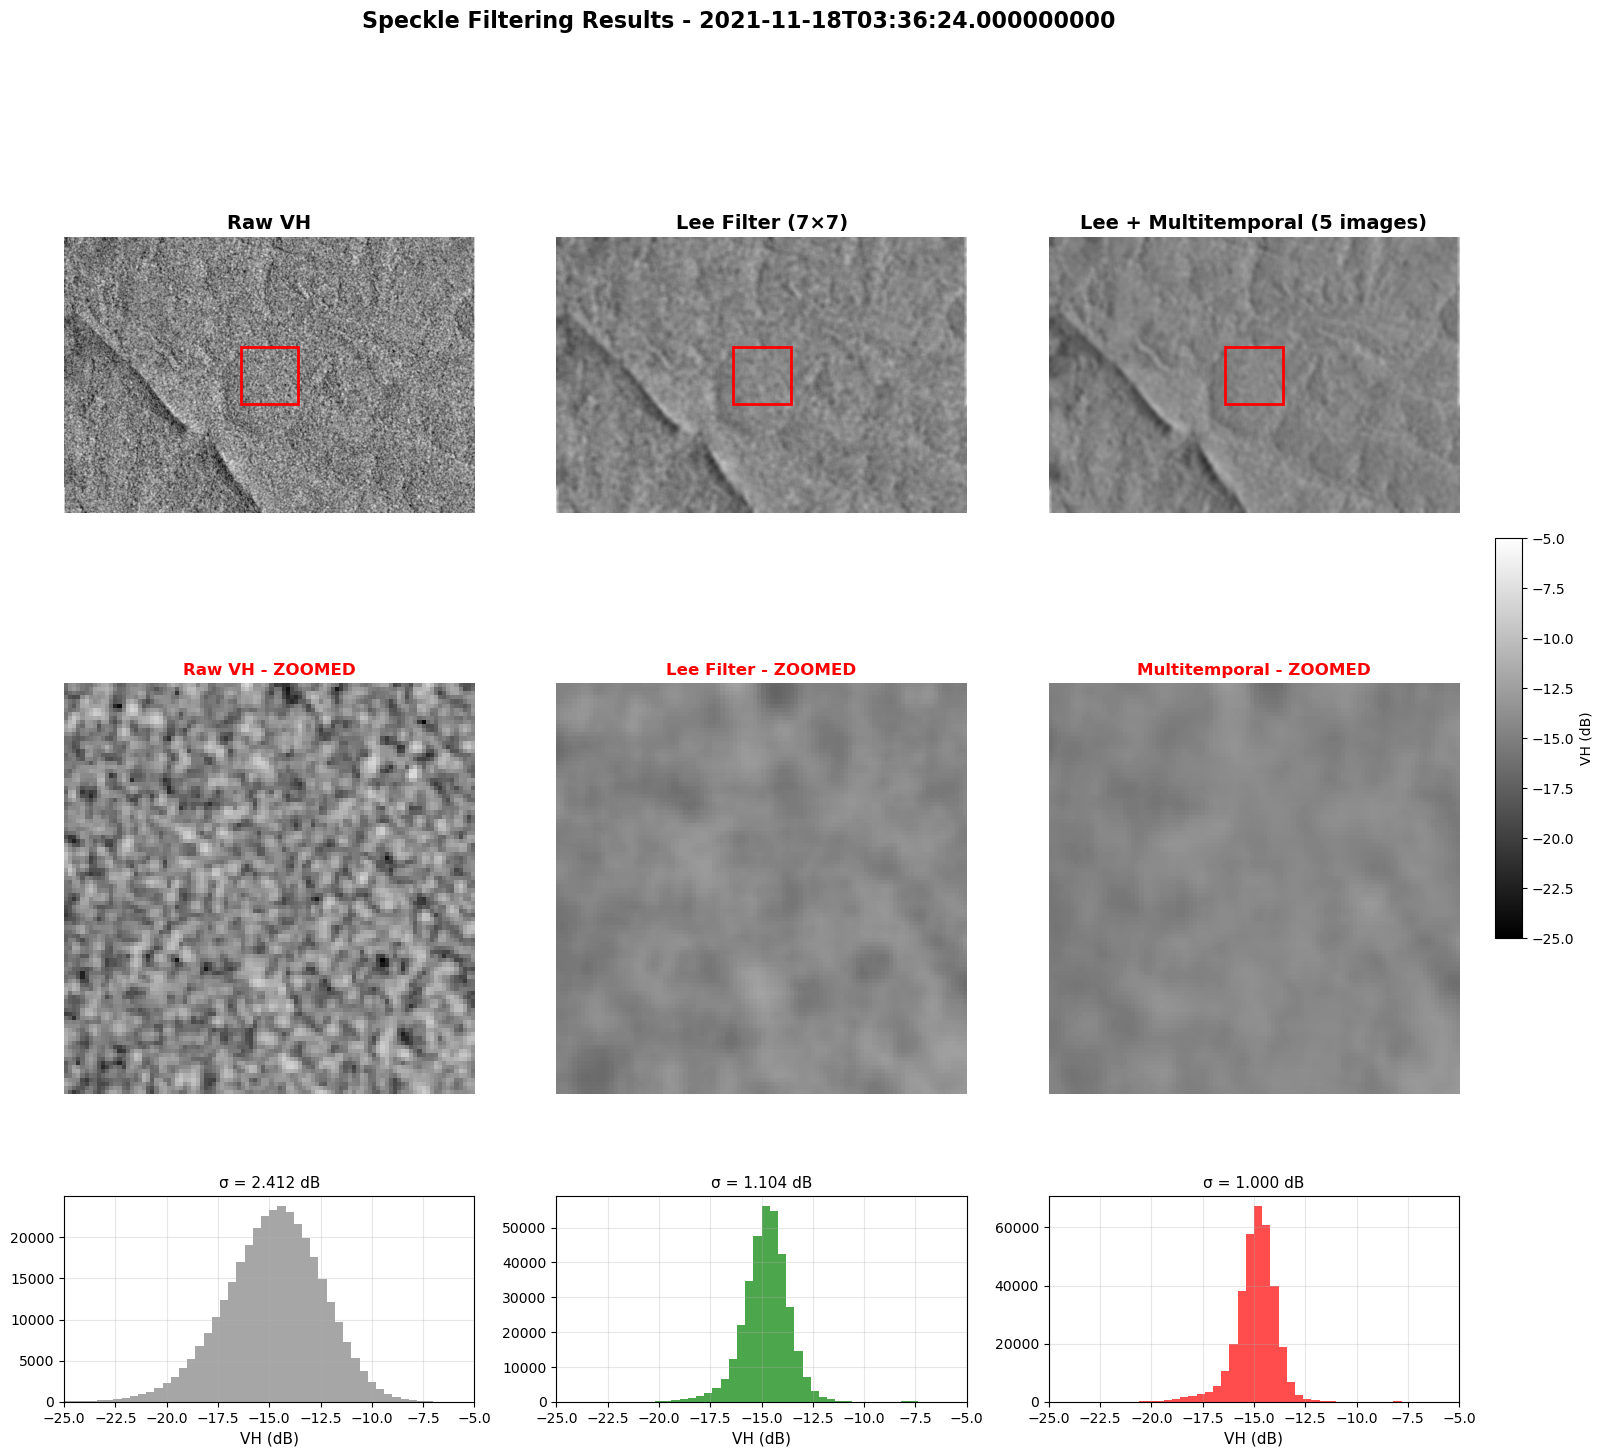


📊 SPECKLE REDUCTION (lower σ = better)
Full image:
  Raw:            σ = 2.412 dB
  Lee Filter:     σ = 1.104 dB  (54.2% reduction)
  Multitemporal:  σ = 1.000 dB  (58.5% reduction)

Zoomed region:
  Raw:            σ = 2.179 dB
  Lee Filter:     σ = 0.676 dB  (69.0% reduction)
  Multitemporal:  σ = 0.506 dB  (76.8% reduction)

✓ Filters successfully reduced speckle noise!


In [30]:
"""
VISUALIZE FILTERING RESULTS - WITH ZOOM
========================================
"""

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ===================== LOAD FILTERED DATA =====================
print("Loading filtered data...")
filtered_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered_w5.nc"
ds = xr.open_dataset(filtered_file)

# Pick a middle timestamp
t = 87  # Mid 2021

vh_raw = ds['VH_raw'][:, :, t].values
vh_lee = ds['VH_lee'][:, :, t].values
vh_filtered = ds['VH_filtered'][:, :, t].values

print(f"Timestamp: {ds.time[t].values}")

# ===================== EXTRACT ZOOM REGION =====================
# Extract 100x100 region from center
ny, nx = vh_raw.shape
center_y, center_x = ny // 2, nx // 2
size = 50

y_start = center_y - size
y_end = center_y + size
x_start = center_x - size
x_end = center_x + size

vh_raw_zoom = vh_raw[y_start:y_end, x_start:x_end]
vh_lee_zoom = vh_lee[y_start:y_end, x_start:x_end]
vh_filtered_zoom = vh_filtered[y_start:y_end, x_start:x_end]

print(f"Zoom region: {vh_raw_zoom.shape}")

# ===================== PLOT =====================
fig = plt.figure(figsize=(18, 16))
gs = fig.add_gridspec(3, 3, height_ratios=[2, 2, 1], hspace=0.3, wspace=0.2)

vmin, vmax = -25, -5

# Row 1: Full images
ax00 = fig.add_subplot(gs[0, 0])
ax00.imshow(vh_raw, cmap='gray', vmin=vmin, vmax=vmax)
ax00.set_title('Raw VH', fontsize=14, fontweight='bold')
ax00.axis('off')
# Mark zoom region
rect = plt.Rectangle((x_start, y_start), 2*size, 2*size, 
                     fill=False, color='red', linewidth=2)
ax00.add_patch(rect)

ax01 = fig.add_subplot(gs[0, 1])
ax01.imshow(vh_lee, cmap='gray', vmin=vmin, vmax=vmax)
ax01.set_title('Lee Filter (7×7)', fontsize=14, fontweight='bold')
ax01.axis('off')
rect = plt.Rectangle((x_start, y_start), 2*size, 2*size, 
                     fill=False, color='red', linewidth=2)
ax01.add_patch(rect)

ax02 = fig.add_subplot(gs[0, 2])
ax02.imshow(vh_filtered, cmap='gray', vmin=vmin, vmax=vmax)
ax02.set_title('Lee + Multitemporal (5 images)', fontsize=14, fontweight='bold')
ax02.axis('off')
rect = plt.Rectangle((x_start, y_start), 2*size, 2*size, 
                     fill=False, color='red', linewidth=2)
ax02.add_patch(rect)

# Row 2: Zoomed images
ax10 = fig.add_subplot(gs[1, 0])
ax10.imshow(vh_raw_zoom, cmap='gray', vmin=vmin, vmax=vmax)
ax10.set_title('Raw VH - ZOOMED', fontsize=12, fontweight='bold', color='red')
ax10.axis('off')

ax11 = fig.add_subplot(gs[1, 1])
ax11.imshow(vh_lee_zoom, cmap='gray', vmin=vmin, vmax=vmax)
ax11.set_title('Lee Filter - ZOOMED', fontsize=12, fontweight='bold', color='red')
ax11.axis('off')

ax12 = fig.add_subplot(gs[1, 2])
im = ax12.imshow(vh_filtered_zoom, cmap='gray', vmin=vmin, vmax=vmax)
ax12.set_title('Multitemporal - ZOOMED', fontsize=12, fontweight='bold', color='red')
ax12.axis('off')

# Add colorbar for zoomed images
cbar_ax = fig.add_axes([0.92, 0.40, 0.015, 0.25])
fig.colorbar(im, cax=cbar_ax, label='VH (dB)')

# Row 3: Histograms
ax20 = fig.add_subplot(gs[2, 0])
ax20.hist(vh_raw.flatten(), bins=50, color='gray', alpha=0.7, range=(vmin, vmax))
ax20.set_xlabel('VH (dB)', fontsize=11)
ax20.set_xlim(vmin, vmax)
ax20.set_title(f'σ = {np.nanstd(vh_raw):.3f} dB', fontsize=11)
ax20.grid(alpha=0.3)

ax21 = fig.add_subplot(gs[2, 1])
ax21.hist(vh_lee.flatten(), bins=50, color='green', alpha=0.7, range=(vmin, vmax))
ax21.set_xlabel('VH (dB)', fontsize=11)
ax21.set_xlim(vmin, vmax)
ax21.set_title(f'σ = {np.nanstd(vh_lee):.3f} dB', fontsize=11)
ax21.grid(alpha=0.3)

ax22 = fig.add_subplot(gs[2, 2])
ax22.hist(vh_filtered.flatten(), bins=50, color='red', alpha=0.7, range=(vmin, vmax))
ax22.set_xlabel('VH (dB)', fontsize=11)
ax22.set_xlim(vmin, vmax)
ax22.set_title(f'σ = {np.nanstd(vh_filtered):.3f} dB', fontsize=11)
ax22.grid(alpha=0.3)

plt.suptitle(f'Speckle Filtering Results - {ds.time[t].values}', 
             fontsize=16, fontweight='bold', y=0.98)

plt.show()

# ===================== STATISTICS =====================
print("\n" + "="*60)
print("📊 SPECKLE REDUCTION (lower σ = better)")
print("="*60)

raw_std = np.nanstd(vh_raw)
lee_std = np.nanstd(vh_lee)
filt_std = np.nanstd(vh_filtered)

print(f"Full image:")
print(f"  Raw:            σ = {raw_std:.3f} dB")
print(f"  Lee Filter:     σ = {lee_std:.3f} dB  ({(1-lee_std/raw_std)*100:.1f}% reduction)")
print(f"  Multitemporal:  σ = {filt_std:.3f} dB  ({(1-filt_std/raw_std)*100:.1f}% reduction)")

raw_zoom_std = np.nanstd(vh_raw_zoom)
lee_zoom_std = np.nanstd(vh_lee_zoom)
filt_zoom_std = np.nanstd(vh_filtered_zoom)

print(f"\nZoomed region:")
print(f"  Raw:            σ = {raw_zoom_std:.3f} dB")
print(f"  Lee Filter:     σ = {lee_zoom_std:.3f} dB  ({(1-lee_zoom_std/raw_zoom_std)*100:.1f}% reduction)")
print(f"  Multitemporal:  σ = {filt_zoom_std:.3f} dB  ({(1-filt_zoom_std/raw_zoom_std)*100:.1f}% reduction)")

print("\n✓ Filters successfully reduced speckle noise!")

## Temporal Variability

In [ ]:
# """
# CALCULATE TEMPORAL VARIABILITY - LOCAL VERSION
# ===============================================
# Adapted from GEE approach, runs on local aligned data
# """

# import xarray as xr
# import numpy as np
# import rasterio
# from scipy.ndimage import zoom
# import matplotlib.pyplot as plt

# # ===================== LOAD FILTERED DATA =====================
# print("="*60)
# print("STEP 1: LOADING DATA")
# print("="*60)

# filtered_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered.nc"
# ds = xr.open_dataset(filtered_file)

# # Use multitemporal filtered data
# vh_data = ds['VH_filtered'].values
# print(f"Loaded: {vh_data.shape}")
# print(f"Date range: {ds.time[0].values} to {ds.time[-1].values}")

# # ===================== LOAD FOREST MASK =====================
# print("\nLoading forest mask...")
# forest_mask_path = "/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2020.tif"

# with rasterio.open(forest_mask_path) as src:
#     forest_array = src.read(1)
#     forest_crs = src.crs

# print(f"Forest mask: {forest_array.shape}")

# # Resample to match S1 grid    <-- reprojec tand clip here!
# if forest_array.shape != vh_data.shape[:2]:
#     zoom_factors = (vh_data.shape[0] / forest_array.shape[0], 
#                     vh_data.shape[1] / forest_array.shape[1])
#     forest_mask = zoom(forest_array, zoom_factors, order=0)
# else:
#     forest_mask = forest_array

# forest_mask = (forest_mask > 0).astype(bool)
# print(f"Resampled forest mask: {forest_mask.shape}")
# print(f"Forest pixels: {forest_mask.sum():,}")

# # ===================== CALCULATE TEMPORAL STATISTICS =====================
# print("\n" + "="*60)
# print("STEP 2: TEMPORAL VARIABILITY")
# print("="*60)

# print("\nCalculating temporal statistics...")

# # Standard deviation over time
# std_dev = np.nanstd(vh_data, axis=2)

# # Percentiles
# p05 = np.nanpercentile(vh_data, 5, axis=2)
# p95 = np.nanpercentile(vh_data, 95, axis=2)

# print("✓ Statistics calculated")

# # ===================== THRESHOLD SELECTION =====================
# # Choose your method
# USE_FIXED_SIGMA = True  # Set to True for manual, False for percentile

# if USE_FIXED_SIGMA:
#     # Manual sigma threshold (dB)
#     tv_threshold = 0.3  # Adjust this value!
#     print(f"\n✓ Using FIXED sigma threshold: {tv_threshold:.3f} dB")
    
# else:
#     # Automatic percentile threshold
#     TV_PERCENTILE = 85
#     # Calculate percentile only within forest mask
#     forest_std = std_dev[forest_mask]
#     tv_threshold = np.nanpercentile(forest_std, TV_PERCENTILE)
#     print(f"\n✓ Using PERCENTILE threshold (p{TV_PERCENTILE}): {tv_threshold:.3f} dB")

# # ===================== FIND CANDIDATE PIXELS =====================
# print("\nFinding candidate pixels...")

# # Create candidate mask (high variability + forest)
# candidate_mask = (std_dev >= tv_threshold) & forest_mask

# n_candidates = candidate_mask.sum()
# n_forest = forest_mask.sum()
# candidate_percent = (n_candidates / n_forest * 100) if n_forest > 0 else 0

# print(f"Candidate pixels: {n_candidates:,} ({candidate_percent:.1f}% of forest)")



STEP 1: LOADING DATA
Loaded: (480, 712, 179)
Date range: 2020-01-04T03:36:10.000000000 to 2024-12-20T03:36:28.000000000

Loading forest mask...
Forest mask: (5284, 7508)
Resampled forest mask: (480, 712)
Forest pixels: 52,041

STEP 2: TEMPORAL VARIABILITY

Calculating temporal statistics...
✓ Statistics calculated

✓ Using FIXED sigma threshold: 0.300 dB

Finding candidate pixels...
Candidate pixels: 52,035 (100.0% of forest)


TEMPORAL VARIABILITY ANALYSIS (WGS84)
S1 data (original): (480, 712, 179)
Date range: 2020-01-04T03:36:10.000000000 to 2024-12-20T03:36:28.000000000

⚠ Applying vertical flip for Hansen alignment...
✓ S1 data (flipped): (480, 712, 179)
Extent: lon [30.926001, 30.989792], lat [1.249092, 1.292398]

Aligning forest mask...
✓ Forest pixels: 301,355 (88.2%)

Calculating temporal statistics...
✓ Statistics calculated
  Std dev: 0.195 to 2.489 dB
  Range (p95-p05): 0.601 to 7.831 dB

  Forest std dev: 0.195 to 2.489 dB
  Mean forest std dev: 0.618 dB
  Forest range: 0.601 to 7.831 dB

CANDIDATE SELECTION
✓ Using FIXED threshold: 0.300 dB
  Equivalent to: p9.8 (lower = more inclusive)
  Candidates: 271,915 (90.2%)

Threshold comparison:
  p50: 0.421 dB → 150,678 pixels ( 50.0%)
  p60: 0.512 dB → 120,542 pixels ( 40.0%)
  p70: 0.672 dB →  90,407 pixels ( 30.0%)
  p80: 0.955 dB →  60,271 pixels ( 20.0%)
  p85: 1.115 dB →  45,204 pixels ( 15.0%)
  p90: 1.264 dB →  30,136 pixels ( 10.0%)
  Fixed: 

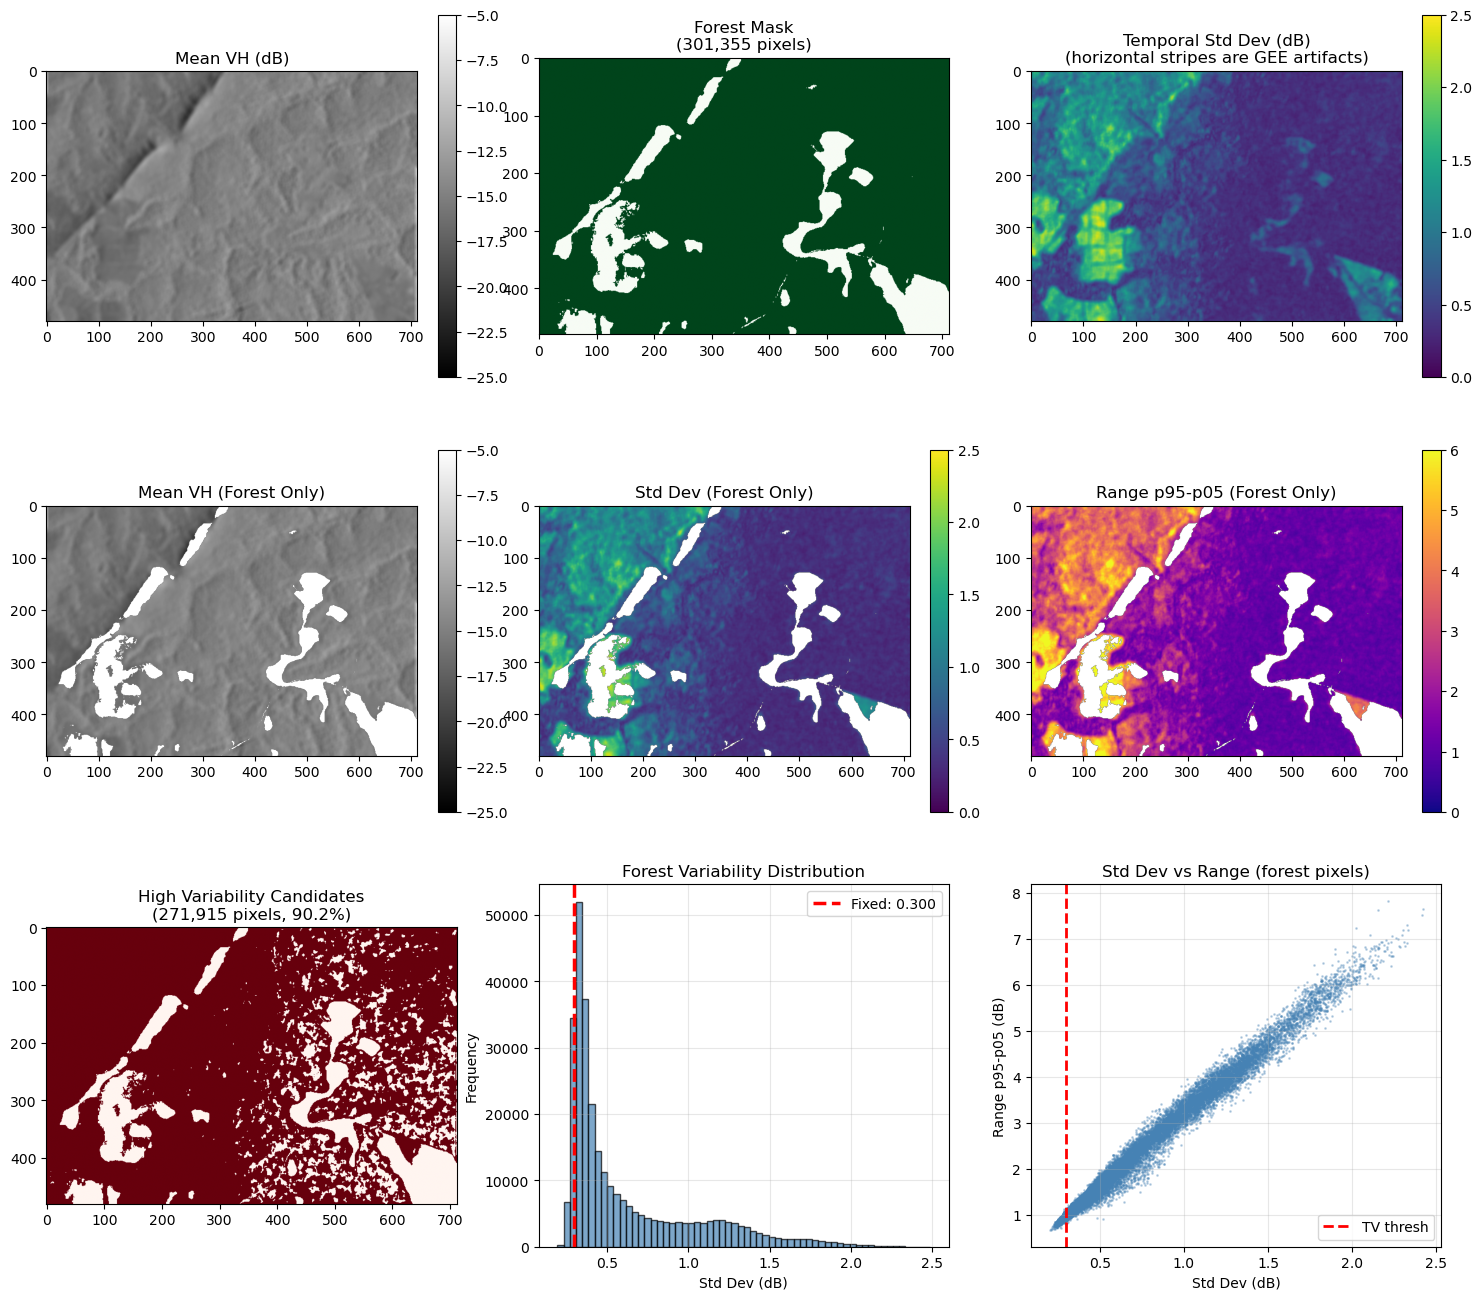

In [31]:
"""
TEMPORAL VARIABILITY - FINAL VERSION (WGS84, ACCEPT STRIPES)
============================================================
Work in original coordinates, stripes are inherent to GEE S1 data
"""

import xarray as xr
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
from rasterio.crs import CRS
import matplotlib.pyplot as plt

# # ===================== LOAD DATA =====================
# print("="*60)
# print("TEMPORAL VARIABILITY ANALYSIS (WGS84)")
# print("="*60)

# filtered_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered.nc"
# ds = xr.open_dataset(filtered_file)

# vh_data = ds['VH_filtered'].values
# print(f"S1 data: {vh_data.shape}")
# print(f"Date range: {ds.time[0].values} to {ds.time[-1].values}")

# # Get S1 grid info
# height, width = vh_data.shape[0], vh_data.shape[1]
# x_min, x_max = ds.x.min().item(), ds.x.max().item()
# y_min, y_max = ds.y.min().item(), ds.y.max().item()

# print(f"Extent: lon [{x_min:.6f}, {x_max:.6f}], lat [{y_min:.6f}, {y_max:.6f}]")

# ===================== LOAD DATA =====================
print("="*60)
print("TEMPORAL VARIABILITY ANALYSIS (WGS84)")
print("="*60)

filtered_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered_w5.nc"
ds = xr.open_dataset(filtered_file)

vh_data = ds['VH_filtered'].values
print(f"S1 data (original): {vh_data.shape}")
print(f"Date range: {ds.time[0].values} to {ds.time[-1].values}")

# APPLY VERTICAL FLIP for correct spatial alignment with Hansen
print("\n⚠ Applying vertical flip for Hansen alignment...")
vh_data = np.flip(vh_data, axis=0)  # Flip along Y dimension (rows)
print(f"✓ S1 data (flipped): {vh_data.shape}")

# Get S1 grid info
height, width = vh_data.shape[0], vh_data.shape[1]
x_min, x_max = ds.x.min().item(), ds.x.max().item()
y_min, y_max = ds.y.min().item(), ds.y.max().item()

# Also flip Y coordinates to match
y_coords_flipped = np.flip(ds.y.values)

print(f"Extent: lon [{x_min:.6f}, {x_max:.6f}], lat [{y_min:.6f}, {y_max:.6f}]")


# ===================== ALIGN FOREST MASK =====================
print("\nAligning forest mask...")

forest_mask_path = "/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2020.tif"
forest_mask = np.zeros((height, width), dtype=np.uint8)

s1_transform = from_bounds(x_min, y_min, x_max, y_max, width, height)
s1_crs = CRS.from_epsg(4326)

with rasterio.open(forest_mask_path) as src:
    reproject(
        source=rasterio.band(src, 1),
        destination=forest_mask,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=s1_transform,
        dst_crs=s1_crs,
        resampling=Resampling.nearest
    )

forest_mask = (forest_mask > 0).astype(bool)
print(f"✓ Forest pixels: {forest_mask.sum():,} ({forest_mask.sum()/forest_mask.size*100:.1f}%)")

# ===================== CALCULATE TEMPORAL STATISTICS =====================
print("\nCalculating temporal statistics...")

# Statistics over time (axis=2)
std_dev = np.nanstd(vh_data, axis=2)
mean_vh = np.nanmean(vh_data, axis=2)
p05 = np.nanpercentile(vh_data, 5, axis=2)
p95 = np.nanpercentile(vh_data, 95, axis=2)

# Range (p95 - p05) as alternative metric
range_vh = p95 - p05

print("✓ Statistics calculated")
print(f"  Std dev: {np.nanmin(std_dev):.3f} to {np.nanmax(std_dev):.3f} dB")
print(f"  Range (p95-p05): {np.nanmin(range_vh):.3f} to {np.nanmax(range_vh):.3f} dB")

if forest_mask.sum() > 0:
    forest_std = std_dev[forest_mask]
    forest_range = range_vh[forest_mask]
    print(f"\n  Forest std dev: {np.nanmin(forest_std):.3f} to {np.nanmax(forest_std):.3f} dB")
    print(f"  Mean forest std dev: {np.nanmean(forest_std):.3f} dB")
    print(f"  Forest range: {np.nanmin(forest_range):.3f} to {np.nanmax(forest_range):.3f} dB")

# ===================== THRESHOLD SELECTION =====================
print("\n" + "="*60)
print("CANDIDATE SELECTION")
print("="*60)

# Choose threshold method
USE_FIXED_SIGMA = True  # Set to True for fixed threshold, False for percentile

if USE_FIXED_SIGMA:
    # Manual fixed threshold (dB)
    FIXED_THRESHOLD = 0.3
    tv_threshold = FIXED_THRESHOLD
    candidate_mask = (std_dev >= tv_threshold) & forest_mask
    
    # Calculate what percentile this represents
    percentile_equiv = np.sum(forest_std < tv_threshold) / len(forest_std) * 100
    
    print(f"✓ Using FIXED threshold: {tv_threshold:.3f} dB")
    print(f"  Equivalent to: p{percentile_equiv:.1f} (lower = more inclusive)")
    print(f"  Candidates: {candidate_mask.sum():,} ({candidate_mask.sum()/forest_mask.sum()*100:.1f}%)")
    
else:
    # Percentile-based threshold
    TV_PERCENTILE = 70  # Lower = more candidates (was 85)
    tv_threshold = np.nanpercentile(forest_std, TV_PERCENTILE)
    candidate_mask = (std_dev >= tv_threshold) & forest_mask
    
    print(f"✓ Using PERCENTILE threshold (p{TV_PERCENTILE}): {tv_threshold:.3f} dB")
    print(f"  Candidates: {candidate_mask.sum():,} ({candidate_mask.sum()/forest_mask.sum()*100:.1f}%)")

# Compare with other potential thresholds for reference
print(f"\nThreshold comparison:")
for p in [50, 60, 70, 80, 85, 90]:
    thresh = np.nanpercentile(forest_std, p)
    n_cand = np.sum((std_dev >= thresh) & forest_mask)
    pct = n_cand / forest_mask.sum() * 100
    marker = " ← CURRENT" if (USE_FIXED_SIGMA and abs(thresh - tv_threshold) < 0.1) or (not USE_FIXED_SIGMA and p == TV_PERCENTILE) else ""
    print(f"  p{p:>2}: {thresh:.3f} dB → {n_cand:>7,} pixels ({pct:>5.1f}%){marker}")

if USE_FIXED_SIGMA:
    print(f"  Fixed: {tv_threshold:.3f} dB → {candidate_mask.sum():>7,} pixels ({candidate_mask.sum()/forest_mask.sum()*100:>5.1f}%) ← CURRENT")

# ===================== VISUALIZATION =====================
fig, axes = plt.subplots(3, 3, figsize=(18, 16))

# Row 1: Basic stats
im1 = axes[0, 0].imshow(mean_vh, cmap='gray', vmin=-25, vmax=-5)
axes[0, 0].set_title('Mean VH (dB)')
plt.colorbar(im1, ax=axes[0, 0], fraction=0.046)

axes[0, 1].imshow(forest_mask, cmap='Greens')
axes[0, 1].set_title(f'Forest Mask\n({forest_mask.sum():,} pixels)')

im3 = axes[0, 2].imshow(std_dev, cmap='viridis', vmin=0, vmax=2.5)
axes[0, 2].set_title('Temporal Std Dev (dB)\n(horizontal stripes are GEE artifacts)')
plt.colorbar(im3, ax=axes[0, 2], fraction=0.046)

# Row 2: Forest-only views
mean_masked = np.where(forest_mask, mean_vh, np.nan)
std_masked = np.where(forest_mask, std_dev, np.nan)
range_masked = np.where(forest_mask, range_vh, np.nan)

im4 = axes[1, 0].imshow(mean_masked, cmap='gray', vmin=-25, vmax=-5)
axes[1, 0].set_title('Mean VH (Forest Only)')
plt.colorbar(im4, ax=axes[1, 0], fraction=0.046)

im5 = axes[1, 1].imshow(std_masked, cmap='viridis', vmin=0, vmax=2.5)
axes[1, 1].set_title('Std Dev (Forest Only)')
plt.colorbar(im5, ax=axes[1, 1], fraction=0.046)

im6 = axes[1, 2].imshow(range_masked, cmap='plasma', vmin=0, vmax=6)
axes[1, 2].set_title('Range p95-p05 (Forest Only)')
plt.colorbar(im6, ax=axes[1, 2], fraction=0.046)

# Row 3: Candidates and distributions
axes[2, 0].imshow(candidate_mask, cmap='Reds')
threshold_label = f"Fixed: {tv_threshold:.3f}" if USE_FIXED_SIGMA else f"p{TV_PERCENTILE}: {tv_threshold:.3f}"
axes[2, 0].set_title(f'High Variability Candidates\n({candidate_mask.sum():,} pixels, {candidate_mask.sum()/forest_mask.sum()*100:.1f}%)')

# Histogram
axes[2, 1].hist(forest_std[~np.isnan(forest_std)], bins=60, alpha=0.7, 
                edgecolor='black', color='steelblue')
axes[2, 1].axvline(tv_threshold, color='red', linestyle='--', linewidth=2.5,
                   label=threshold_label)
axes[2, 1].set_xlabel('Std Dev (dB)')
axes[2, 1].set_ylabel('Frequency')
axes[2, 1].set_title('Forest Variability Distribution')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

# Comparison: std vs range methods
axes[2, 2].scatter(std_dev[forest_mask][::10], range_vh[forest_mask][::10], 
                  alpha=0.3, s=1, c='steelblue')
axes[2, 2].axvline(tv_threshold, color='red', linestyle='--', linewidth=2, label='TV thresh')
axes[2, 2].set_xlabel('Std Dev (dB)')
axes[2, 2].set_ylabel('Range p95-p05 (dB)')
axes[2, 2].set_title('Std Dev vs Range (forest pixels)')
axes[2, 2].legend()
axes[2, 2].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig('temporal_variability_final.png', dpi=150, bbox_inches='tight')
# print("\n✓ Saved: temporal_variability_final.png")
# plt.show()

# ===================== SAVE RESULTS =====================
print("\nSaving results...")

# Close input datasets to release file locks
ds.close()
if 'ds_tv' in locals():
    ds_tv.close()

output_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/temporal_variability_w5.nc"

ds_out = xr.Dataset({
    'std_dev': (['y', 'x'], std_dev),
    'mean_vh': (['y', 'x'], mean_vh),
    'p05': (['y', 'x'], p05),
    'p95': (['y', 'x'], p95),
    'range_vh': (['y', 'x'], range_vh),
    'forest_mask': (['y', 'x'], forest_mask),
    'candidate_mask': (['y', 'x'], candidate_mask)
}, coords={'x': ds.x.values, 'y': ds.y.values})  # Use .values to copy

# Build attributes based on threshold method
attrs = {
    'crs': 'EPSG:4326',
    'tv_threshold': float(tv_threshold),
    'threshold_method': 'fixed' if USE_FIXED_SIGMA else 'percentile',
    'description': 'Temporal variability analysis for change detection',
    'note': 'Horizontal stripes are GEE S1 processing artifacts (sub-swath boundaries)'
}

# Add method-specific attributes (avoid None values)
if USE_FIXED_SIGMA:
    attrs['fixed_threshold'] = float(FIXED_THRESHOLD)
else:
    attrs['std_percentile'] = int(TV_PERCENTILE)

ds_out.attrs.update(attrs)

ds_out.to_netcdf(output_file)
print(f"✓ Saved: {output_file}")

In [32]:
# ===================== SAVE RESULTS =====================
print("\nSaving results...")

# Close input datasets to release file locks
ds.close()
if 'ds_tv' in locals():
    ds_tv.close()

output_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/temporal_variability_w5.nc"

ds_out = xr.Dataset({
    'std_dev': (['y', 'x'], std_dev),
    'mean_vh': (['y', 'x'], mean_vh),
    'p05': (['y', 'x'], p05),
    'p95': (['y', 'x'], p95),
    'range_vh': (['y', 'x'], range_vh),
    'forest_mask': (['y', 'x'], forest_mask),
    'candidate_mask': (['y', 'x'], candidate_mask)
}, coords={'x': ds.x.values, 'y': ds.y.values})  # Use .values to copy

# Build attributes based on threshold method
attrs = {
    'crs': 'EPSG:4326',
    'tv_threshold': float(tv_threshold),
    'threshold_method': 'fixed' if USE_FIXED_SIGMA else 'percentile',
    'description': 'Temporal variability analysis for change detection',
    'note': 'Horizontal stripes are GEE S1 processing artifacts (sub-swath boundaries)'
}

# Add method-specific attributes (avoid None values)
if USE_FIXED_SIGMA:
    attrs['fixed_threshold'] = float(FIXED_THRESHOLD)
else:
    attrs['std_percentile'] = int(TV_PERCENTILE)

ds_out.attrs.update(attrs)

ds_out.to_netcdf(output_file)
print(f"✓ Saved: {output_file}")


Saving results...
✓ Saved: /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/temporal_variability_w5.nc


## Logistic Fitting

In [ ]:
# """
# LOGISTIC FITTING - LOCAL VERSION
# =================================
# Fits logistic curves to detect deforestation timing
# """

# import numpy as np
# import pickle
# from datetime import datetime, timedelta
# import matplotlib.pyplot as plt
# import xarray as xr

# # ===================== LOAD DATA =====================
# print("="*60)
# print("STEP 3: LOGISTIC FITTING")
# print("="*60)

# # Load filtered data
# print("\nLoading filtered data...")
# filtered_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered.nc"
# ds = xr.open_dataset(filtered_file)
# vh_data = ds['VH_filtered'].values

# # Load temporal variability results
# print("Loading temporal variability results...")
# with open("/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/temporal_variability.pkl", 'rb') as f:
#     tv_results = pickle.load(f)

# std_dev = tv_results['std_dev']
# p05 = tv_results['p05']
# p95 = tv_results['p95']
# candidate_mask = tv_results['candidate_mask']
# forest_mask = tv_results['forest_mask']

# print(f"Time series length: {vh_data.shape[2]} images")
# print(f"Candidates: {candidate_mask.sum():,} pixels")

# # ===================== CALCULATE PARAMETERS =====================
# print("\nCalculating parameters...")

# amp = p95 - p05
# flattening = amp / np.abs(p95)

# print(f"Amplitude range: {np.nanmin(amp):.2f} to {np.nanmax(amp):.2f} dB")
# print(f"Flattening range: {np.nanmin(flattening):.3f} to {np.nanmax(flattening):.3f}")

# # ===================== FIT LOGISTIC CURVES =====================
# print("\nFitting logistic curves...")

# # Parameters
# A_STEEPNESS = -2.0
# N_WINDOW = 5
# M = vh_data.shape[2]

# # Valid t0 range
# idx_min = N_WINDOW
# idx_max = M - N_WINDOW - 1
# t0_candidates = np.arange(idx_min, idx_max + 1)

# print(f"Testing {len(t0_candidates)} inflection points per pixel...")
# print(f"Steepness: {A_STEEPNESS}, Window: ±{N_WINDOW}")

# def fit_logistic_pixel(time_series, lower, amp, a_steepness, n_window, t0_candidates):
#     """
#     Fit logistic curve to single pixel time series
#     Returns best t0 and minimum SSE
#     """
#     M = len(time_series)
#     obs_idx = np.arange(M)
    
#     best_sse = np.inf
#     best_t0 = None
    
#     for t0 in t0_candidates:
#         # Logistic function: k / (1 + e^(-a(t-t0))) + lower
#         exponent = -a_steepness * (obs_idx - t0)
#         y_pred = amp / (1 + np.exp(exponent)) + lower
        
#         # Calculate residuals within window
#         in_window = (obs_idx >= t0 - n_window) & (obs_idx <= t0 + n_window)
#         residuals = time_series[in_window] - y_pred[in_window]
        
#         # SSE (only on valid data)
#         valid = ~np.isnan(residuals)
#         if valid.sum() > 0:
#             sse = np.sum(residuals[valid]**2)
            
#             if sse < best_sse:
#                 best_sse = sse
#                 best_t0 = t0
    
#     return best_t0, best_sse

# # Initialize output arrays
# best_t0_map = np.full(vh_data.shape[:2], np.nan)
# best_sse_map = np.full(vh_data.shape[:2], np.nan)

# # Get candidate pixel locations
# candidate_rows, candidate_cols = np.where(candidate_mask)
# n_candidates = len(candidate_rows)

# print(f"\nProcessing {n_candidates:,} candidate pixels...")

# # Process each candidate pixel
# for idx, (i, j) in enumerate(zip(candidate_rows, candidate_cols)):
#     if idx % 1000 == 0:
#         print(f"  {idx:,}/{n_candidates:,} ({idx/n_candidates*100:.1f}%)...")
    
#     # Get time series
#     ts = vh_data[i, j, :]
    
#     # Skip if too many NaN values
#     if np.sum(~np.isnan(ts)) < M * 0.5:
#         continue
    
#     # Fit logistic
#     t0, sse = fit_logistic_pixel(
#         ts, 
#         lower=p05[i, j], 
#         amp=amp[i, j],
#         a_steepness=A_STEEPNESS,
#         n_window=N_WINDOW,
#         t0_candidates=t0_candidates
#     )
    
#     best_t0_map[i, j] = t0
#     best_sse_map[i, j] = sse

# print(f"✓ Fitting complete!")
# print(f"  Valid fits: {np.sum(~np.isnan(best_t0_map)):,}")

# # ===================== CONVERT TO DATES (SIMPLER VERSION) =====================
# print("\nConverting indices to dates...")

# import pandas as pd

# # Get time array
# time_array = ds.time.values

# # Average interval
# time_diffs = np.diff(time_array.astype('datetime64[D]').astype(int))
# avg_interval_days = np.median(time_diffs)
# print(f"Average interval: {avg_interval_days:.1f} days")

# # Convert t0 to dates
# defor_dates = np.full(vh_data.shape[:2], np.datetime64('NaT'), dtype='datetime64[ns]')
# defor_years = np.full(vh_data.shape[:2], np.nan)

# valid_t0 = ~np.isnan(best_t0_map)
# for i, j in zip(*np.where(valid_t0)):
#     t0_idx = int(best_t0_map[i, j])
    
#     # Get date
#     defor_dates[i, j] = time_array[t0_idx]
    
#     # Convert to decimal year using pandas
#     ts = pd.Timestamp(time_array[t0_idx])
#     day_of_year = ts.dayofyear
#     days_in_year = 366 if ts.is_leap_year else 365
#     defor_years[i, j] = ts.year + (day_of_year - 1) / days_in_year

# print(f"✓ Date conversion complete")
# print(f"  Date range: {np.nanmin(defor_years):.2f} to {np.nanmax(defor_years):.2f}")
# # ===================== CREATE FINAL MASK =====================
# print("\nCreating deforestation mask...")

# FLAT_THRESH = 0.14
# SSE_THRESH = 50.0  # Adjust as needed

# defor_mask = (
#     candidate_mask &
#     (flattening >= FLAT_THRESH) &
#     (~np.isnan(best_t0_map)) &
#     (best_sse_map < SSE_THRESH)
# )

# n_defor = defor_mask.sum()
# print(f"✓ Deforestation pixels: {n_defor:,}")
# print(f"  Flattening threshold: {FLAT_THRESH}")
# print(f"  SSE threshold: {SSE_THRESH}")


STEP 3: LOGISTIC FITTING

Loading filtered data...
Loading temporal variability results...
Time series length: 179 images
Candidates: 52,035 pixels

Calculating parameters...
Amplitude range: 0.31 to 8.76 dB
Flattening range: 0.055 to 0.716

Fitting logistic curves...
Testing 169 inflection points per pixel...
Steepness: -2.0, Window: ±5

Processing 52,035 candidate pixels...
  0/52,035 (0.0%)...
  1,000/52,035 (1.9%)...
  2,000/52,035 (3.8%)...
  3,000/52,035 (5.8%)...
  4,000/52,035 (7.7%)...
  5,000/52,035 (9.6%)...
  6,000/52,035 (11.5%)...
  7,000/52,035 (13.5%)...
  8,000/52,035 (15.4%)...
  9,000/52,035 (17.3%)...
  10,000/52,035 (19.2%)...
  11,000/52,035 (21.1%)...
  12,000/52,035 (23.1%)...
  13,000/52,035 (25.0%)...
  14,000/52,035 (26.9%)...
  15,000/52,035 (28.8%)...
  16,000/52,035 (30.7%)...
  17,000/52,035 (32.7%)...
  18,000/52,035 (34.6%)...
  19,000/52,035 (36.5%)...
  20,000/52,035 (38.4%)...
  21,000/52,035 (40.4%)...
  22,000/52,035 (42.3%)...
  23,000/52,035 (44.

In [ ]:
"""
LOGISTIC FITTING - LOCAL VERSION (FIXED)
=========================================
Fits logistic curves to detect deforestation timing
"""

import numpy as np
import xarray as xr
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt


# ===================== LOAD DATA =====================
print("="*60)
print("STEP 3: LOGISTIC FITTING")
print("="*60)

# Load filtered data
print("\nLoading filtered data...")
filtered_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered.nc"
ds = xr.open_dataset(filtered_file)
vh_data = ds['VH_filtered'].values
time_array = ds.time.values

print(f"VH data: {vh_data.shape}")
print(f"Time series length: {vh_data.shape[2]} images")

# Load temporal variability results
print("Loading temporal variability results...")
tv_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/temporal_variability.nc"
ds_tv = xr.open_dataset(tv_file)

std_dev = ds_tv['std_dev'].values
p05 = ds_tv['p05'].values
p95 = ds_tv['p95'].values
candidate_mask = ds_tv['candidate_mask'].values
forest_mask = ds_tv['forest_mask'].values

print(f"✓ Loaded temporal variability results")
print(f"  Candidates: {candidate_mask.sum():,} pixels")
print(f"  Forest pixels: {forest_mask.sum():,}")

# ===================== CALCULATE PARAMETERS =====================
print("Calculating parameters...")

amp = p95 - p05
flattening = amp / np.abs(p05)

print(f"Amplitude range: {np.nanmin(amp):.2f} to {np.nanmax(amp):.2f} dB")
print(f"Flattening range: {np.nanmin(flattening):.3f} to {np.nanmax(flattening):.3f}")

# ===================== FIT LOGISTIC CURVES =====================
print("\n" + "="*60)
print("FITTING LOGISTIC CURVES")
print("="*60)

# Parameters
A_STEEPNESS = -2.0
N_WINDOW = 5
M = vh_data.shape[2]

# Valid t0 range
idx_min = N_WINDOW
idx_max = M - N_WINDOW - 1
t0_candidates = np.arange(idx_min, idx_max + 1)

print(f"Configuration:")
print(f"  Steepness (a): {A_STEEPNESS}")
print(f"  Window size: ±{N_WINDOW} images")
print(f"  Testing {len(t0_candidates)} inflection points per pixel")
print(f"  Valid range: image {idx_min} to {idx_max}")

def fit_logistic_pixel(time_series, lower, amp, a_steepness, n_window, t0_candidates):
    """Fit logistic curve to single pixel time series"""
    M = len(time_series)
    obs_idx = np.arange(M)
    
    best_sse = np.inf
    best_t0 = None
    
    for t0 in t0_candidates:
        exponent = -a_steepness * (obs_idx - t0)
        exponent = np.clip(exponent, -50, 50)
        y_pred = amp / (1 + np.exp(exponent)) + lower
        
        in_window = (obs_idx >= t0 - n_window) & (obs_idx <= t0 + n_window)
        residuals = time_series[in_window] - y_pred[in_window]
        
        valid = ~np.isnan(residuals)
        if valid.sum() > 0:
            sse = np.sum(residuals[valid]**2)
            
            if sse < best_sse:
                best_sse = sse
                best_t0 = t0
    
    return best_t0, best_sse

# Initialize output arrays
best_t0_map = np.full(vh_data.shape[:2], np.nan)
best_sse_map = np.full(vh_data.shape[:2], np.nan)

# Get candidate pixel locations
candidate_rows, candidate_cols = np.where(candidate_mask)
n_candidates = len(candidate_rows)

print(f"\nProcessing {n_candidates:,} candidate pixels...")

# Process each candidate pixel
for idx, (i, j) in enumerate(zip(candidate_rows, candidate_cols)):
    if idx % 1000 == 0:
        print(f"  Progress: {idx:,}/{n_candidates:,} ({idx/n_candidates*100:.1f}%)...")
    
    ts = vh_data[i, j, :]
    
    if np.sum(~np.isnan(ts)) < M * 0.5:
        continue
    
    t0, sse = fit_logistic_pixel(
        ts, 
        lower=p05[i, j], 
        amp=amp[i, j],
        a_steepness=A_STEEPNESS,
        n_window=N_WINDOW,
        t0_candidates=t0_candidates
    )
    
    best_t0_map[i, j] = t0
    best_sse_map[i, j] = sse

print(f"✓ Fitting complete!")
print(f"  Valid fits: {np.sum(~np.isnan(best_t0_map)):,}")

# ===================== SSE DISTRIBUTION =====================
print("\n" + "="*60)
print("SSE DISTRIBUTION & THRESHOLD SELECTION")
print("="*60)

valid_sse = best_sse_map[~np.isnan(best_sse_map)]

if len(valid_sse) > 0:
    print(f"SSE statistics:")
    print(f"  Min: {np.min(valid_sse):.2f}")
    print(f"  Median (p50): {np.percentile(valid_sse, 50):.2f}")
    print(f"  p75: {np.percentile(valid_sse, 75):.2f}")
    print(f"  p85: {np.percentile(valid_sse, 85):.2f}")
    print(f"  p90: {np.percentile(valid_sse, 90):.2f}")
    print(f"  p95: {np.percentile(valid_sse, 95):.2f}")
    print(f"  Max: {np.max(valid_sse):.2f}")
    
    sse_p75 = np.percentile(valid_sse, 75)
    sse_p85 = np.percentile(valid_sse, 85)
    sse_p90 = np.percentile(valid_sse, 90)
    
    print(f"\nSuggested SSE thresholds:")
    print(f"  Conservative (keep 75% best fits): {sse_p75:.2f}")
    print(f"  Moderate (keep 85% best fits): {sse_p85:.2f}")
    print(f"  Permissive (keep 90% best fits): {sse_p90:.2f}")
    
    # Visualize SSE
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(valid_sse, bins=100, edgecolor='black', alpha=0.7)
    axes[0].axvline(sse_p75, color='green', linestyle='--', linewidth=2, label=f'p75: {sse_p75:.1f}')
    axes[0].axvline(sse_p85, color='orange', linestyle='--', linewidth=2, label=f'p85: {sse_p85:.1f}')
    axes[0].axvline(sse_p90, color='red', linestyle='--', linewidth=2, label=f'p90: {sse_p90:.1f}')
    axes[0].set_xlabel('SSE')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('SSE Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(valid_sse, bins=100, edgecolor='black', alpha=0.7)
    axes[1].axvline(sse_p75, color='green', linestyle='--', linewidth=2, label=f'p75: {sse_p75:.1f}')
    axes[1].axvline(sse_p85, color='orange', linestyle='--', linewidth=2, label=f'p85: {sse_p85:.1f}')
    axes[1].axvline(sse_p90, color='red', linestyle='--', linewidth=2, label=f'p90: {sse_p90:.1f}')
    axes[1].set_xlabel('SSE')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('SSE Distribution (log scale)')
    axes[1].set_yscale('log')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('sse_distribution.png', dpi=150)
    print("\n✓ Saved: sse_distribution.png")
    plt.show()

# ===================== CONVERT TO DATES =====================
print("\n" + "="*60)
print("CONVERTING INDICES TO DATES")
print("="*60)

defor_dates = np.full(vh_data.shape[:2], np.datetime64('NaT'), dtype='datetime64[ns]')
defor_years = np.full(vh_data.shape[:2], np.nan)

valid_t0 = ~np.isnan(best_t0_map)
for i, j in zip(*np.where(valid_t0)):
    t0_idx = int(best_t0_map[i, j])
    defor_dates[i, j] = time_array[t0_idx]
    
    ts = pd.Timestamp(time_array[t0_idx])
    day_of_year = ts.dayofyear
    days_in_year = 366 if ts.is_leap_year else 365
    defor_years[i, j] = ts.year + (day_of_year - 1) / days_in_year

print(f"✓ Date conversion complete")
if np.sum(~np.isnan(defor_years)) > 0:
    print(f"  Date range: {np.nanmin(defor_years):.2f} to {np.nanmax(defor_years):.2f}")

# ===================== CREATE DEFORESTATION MASKS =====================
print("\n" + "="*60)
print("CREATING DEFORESTATION MASKS")
print("="*60)

FLAT_THRESH = 0.12

SSE_THRESHOLDS = {
    'conservative': sse_p75 if len(valid_sse) > 0 else 140.0,
    'moderate': sse_p85 if len(valid_sse) > 0 else 160.0,
    'permissive': sse_p90 if len(valid_sse) > 0 else 180.0
}

defor_masks = {}

for name, sse_thresh in SSE_THRESHOLDS.items():
    defor_mask = (
        candidate_mask &
        (flattening >= FLAT_THRESH) &
        (~np.isnan(best_t0_map)) &
        (best_sse_map < sse_thresh)
    )
    
    defor_masks[name] = defor_mask
    n_defor = defor_mask.sum()
    
    print(f"{name.capitalize()} (SSE < {sse_thresh:.1f}):")
    print(f"  Deforestation pixels: {n_defor:,} ({n_defor/forest_mask.sum()*100:.2f}% of forest)")

# Use moderate as default
defor_mask = defor_masks['moderate']

# ===================== VISUALIZATION (FIXED) =====================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Row 1
im1 = axes[0, 0].imshow(best_sse_map, cmap='viridis', vmin=0, vmax=np.percentile(valid_sse, 95))
axes[0, 0].set_title('SSE (fit quality)')
plt.colorbar(im1, ax=axes[0, 0], fraction=0.046)

im2 = axes[0, 1].imshow(flattening, cmap='plasma', vmin=0, vmax=0.5)
axes[0, 1].set_title(f'Flattening (threshold: {FLAT_THRESH})')
plt.colorbar(im2, ax=axes[0, 1], fraction=0.046)

# Row 2
defor_years_masked = np.where(defor_mask, defor_years, np.nan)
im3 = axes[1, 0].imshow(defor_years_masked, cmap='RdYlGn_r', vmin=2020, vmax=2025)
axes[1, 0].set_title('Deforestation Year')
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046)

axes[1, 1].imshow(defor_mask, cmap='Reds')
axes[1, 1].set_title(f'Deforestation Mask (Moderate)\n({defor_mask.sum():,} pixels)')

plt.tight_layout()
plt.savefig('logistic_fitting_results.png', dpi=150)
print("\n✓ Saved: logistic_fitting_results.png")
plt.show()

# Compare thresholds
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, mask) in enumerate(defor_masks.items()):
    axes[idx].imshow(mask, cmap='Reds')
    axes[idx].set_title(f'{name.capitalize()}\n({mask.sum():,} pixels)')
    axes[idx].axis('off')
plt.tight_layout()
plt.savefig('deforestation_thresholds_comparison.png', dpi=150)
print("✓ Saved: deforestation_thresholds_comparison.png")
plt.show()


# ===================== SAVE RESULTS =====================
print("\nSaving results...")

# Close all open datasets to release file locks
ds.close()
ds_tv.close()
if 'ds_log' in locals():
    ds_log.close()

output_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/logistic_fitting_f012_sse140_180.nc"

x_coords = ds.x.values.copy()  # Copy values before closing
y_coords = ds.y.values.copy()

ds_out = xr.Dataset({
    'best_t0': (['y', 'x'], best_t0_map),
    'best_sse': (['y', 'x'], best_sse_map),
    'flattening': (['y', 'x'], flattening),
    'amplitude': (['y', 'x'], amp),
    'defor_years': (['y', 'x'], defor_years),
    'defor_mask': (['y', 'x'], defor_mask),
    'defor_mask_conservative': (['y', 'x'], defor_masks['conservative']),
    'defor_mask_permissive': (['y', 'x'], defor_masks['permissive']),
}, coords={'x': x_coords, 'y': y_coords})

ds_out.attrs.update({
    'crs': 'EPSG:4326',
    'a_steepness': A_STEEPNESS,
    'n_window': N_WINDOW,
    'flat_threshold': FLAT_THRESH,
    'sse_threshold_moderate': SSE_THRESHOLDS['moderate'],
    'sse_threshold_conservative': SSE_THRESHOLDS['conservative'],
    'sse_threshold_permissive': SSE_THRESHOLDS['permissive'],
})

ds_out.to_netcdf(output_file)
print(f"✓ Saved: {output_file}")


STEP 3: LOGISTIC FITTING

Loading filtered data...
VH data: (480, 712, 179)
Time series length: 179 images
Loading temporal variability results...
✓ Loaded temporal variability results
  Candidates: 301,090 pixels
  Forest pixels: 301,355
Calculating parameters...
Amplitude range: 0.31 to 8.76 dB
Flattening range: 0.052 to 0.417

FITTING LOGISTIC CURVES
Configuration:
  Steepness (a): -2.0
  Window size: ±5 images
  Testing 169 inflection points per pixel
  Valid range: image 5 to 173

Processing 301,090 candidate pixels...
  Progress: 0/301,090 (0.0%)...
  Progress: 1,000/301,090 (0.3%)...
  Progress: 2,000/301,090 (0.7%)...
  Progress: 3,000/301,090 (1.0%)...
  Progress: 4,000/301,090 (1.3%)...
  Progress: 5,000/301,090 (1.7%)...
  Progress: 6,000/301,090 (2.0%)...
  Progress: 7,000/301,090 (2.3%)...
  Progress: 8,000/301,090 (2.7%)...
  Progress: 9,000/301,090 (3.0%)...
  Progress: 10,000/301,090 (3.3%)...
  Progress: 11,000/301,090 (3.7%)...
  Progress: 12,000/301,090 (4.0%)...
  P

In [41]:

# ===================== SAVE RESULTS =====================
print("\nSaving results...")

# Close all open datasets to release file locks
ds.close()
ds_tv.close()
if 'ds_log' in locals():
    ds_log.close()

output_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/logistic_fitting_f012.nc"

x_coords = ds.x.values.copy()  # Copy values before closing
y_coords = ds.y.values.copy()

ds_out = xr.Dataset({
    'best_t0': (['y', 'x'], best_t0_map),
    'best_sse': (['y', 'x'], best_sse_map),
    'flattening': (['y', 'x'], flattening),
    'amplitude': (['y', 'x'], amp),
    'defor_years': (['y', 'x'], defor_years),
    'defor_mask': (['y', 'x'], defor_mask),
    'defor_mask_conservative': (['y', 'x'], defor_masks['conservative']),
    'defor_mask_permissive': (['y', 'x'], defor_masks['permissive']),
}, coords={'x': x_coords, 'y': y_coords})

ds_out.attrs.update({
    'crs': 'EPSG:4326',
    'a_steepness': A_STEEPNESS,
    'n_window': N_WINDOW,
    'flat_threshold': FLAT_THRESH,
    'sse_threshold_moderate': SSE_THRESHOLDS['moderate'],
    'sse_threshold_conservative': SSE_THRESHOLDS['conservative'],
    'sse_threshold_permissive': SSE_THRESHOLDS['permissive'],
})

ds_out.to_netcdf(output_file)
print(f"✓ Saved: {output_file}")



Saving results...
✓ Saved: /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/logistic_fitting_f012.nc


In [36]:
ds_out

<xarray.Dataset> Size: 15MB
Dimensions:                  (y: 480, x: 712)
Coordinates:
  * x                        (x) float64 6kB 30.93 30.93 30.93 ... 30.99 30.99
  * y                        (y) float64 4kB 1.292 1.292 1.292 ... 1.249 1.249
Data variables:
    best_t0                  (y, x) float64 3MB 128.0 128.0 155.0 ... nan nan
    best_sse                 (y, x) float64 3MB 1.653e+03 109.1 ... nan nan
    flattening               (y, x) float64 3MB 0.2853 0.2922 ... 0.1852 0.1712
    amplitude                (y, x) float64 3MB 1.097 4.654 ... 2.672 0.5996
    defor_years              (y, x) float64 3MB 2.023e+03 2.023e+03 ... nan nan
    defor_mask               (y, x) bool 342kB False False False ... False False
    defor_mask_conservative  (y, x) bool 342kB False False False ... False False
    defor_mask_permissive    (y, x) bool 342kB False False False ... False False
Attributes:
    crs:                         EPSG:4326
    a_steepness:                 -2.0
    n_window:                    5
    flat_threshold:              0.12
    sse_threshold_moderate:      21.267921764031414
    sse_threshold_conservative:  12.494878572707757
    sse_threshold_permissive:    30.04160742960535

In [ ]:
defor_mask = defor_masks['permissive']

# ===================== CREATE DEFORESTATION MASKS =====================
print("\n" + "="*60)
print("CREATING DEFORESTATION MASKS")
print("="*60)

# Use higher thresholds that actually matter
FLAT_THRESHOLDS = {
    'low': 0.14,      # Excludes ~1% 
    'medium': 0.16,   # Excludes ~2%
    'high': 0.18      # Excludes ~10%
}

SSE_THRESHOLDS = {
    'conservative': sse_p75 if len(valid_sse) > 0 else 30.0,
    'moderate': sse_p85 if len(valid_sse) > 0 else 50.0,
    'permissive': sse_p90 if len(valid_sse) > 0 else 80.0
}

# Try all combinations
print("\nDeforestation pixels by threshold combination:\n")
print(f"{'SSE Thresh':<15} {'Flat=0.14':<12} {'Flat=0.16':<12} {'Flat=0.18':<12}")
print("-" * 55)

results = {}

for sse_name, sse_thresh in SSE_THRESHOLDS.items():
    row = [f"{sse_name}"]
    for flat_name, flat_thresh in FLAT_THRESHOLDS.items():
        mask = (
            candidate_mask &
            (flattening >= flat_thresh) &
            (~np.isnan(best_t0_map)) &
            (best_sse_map < sse_thresh)
        )
        n_pixels = mask.sum()
        row.append(f"{n_pixels:>7,}")
        results[f"{sse_name}_{flat_name}"] = mask
    
    print(f"{row[0]:<15} {row[1]:<12} {row[2]:<12} {row[3]:<12}")

# Use moderate SSE + medium flattening as default
defor_mask = (
    candidate_mask &
    (flattening >= 0.20) &
    (~np.isnan(best_t0_map)) &
    (best_sse_map < SSE_THRESHOLDS['moderate'])
)

print(f"\n✓ Using moderate SSE (p85) + flattening >= 0.20")
print(f"✓ Deforestation pixels: {defor_mask.sum():,}")


CREATING DEFORESTATION MASKS

Deforestation pixels by threshold combination:

SSE Thresh      Flat=0.18    Flat=0.20    Flat=0.23   
-------------------------------------------------------
conservative     45,746       27,772       16,661     
moderate         73,588       50,589       34,072     
permissive       88,461       64,608       46,068     

✓ Using moderate SSE (p85) + flattening >= 0.20
✓ Deforestation pixels: 21,339


## Compare to Hansen

LOADING DEFORESTATION RESULTS
Your deforestation mask: (480, 712)
Extent: [30.926001, 30.989792] x [1.249092, 1.292398]
Detected pixels: 73,588

LOADING HANSEN DATA
Hansen CRS: EPSG:4326
Hansen shape: (40000, 40000)
✓ Hansen reprojected to S1 grid: (480, 712)
✓ Hansen loss 2020-2024: 178,077 pixels

VALIDATION METRICS
Your detections:     73,588 pixels
Hansen reference:    178,077 pixels

Agreement:
  Both agree:        58,861 pixels
  Only you:          14,727 pixels (commission)
  Only Hansen:       119,216 pixels (omission)

Metrics:
  Precision:         80.0% (your detections that are correct)
  Recall:            33.1% (Hansen detections you captured)
  F1 Score:          46.8% (overall agreement)

Creating comparison plots...
✓ Saved: hansen_comparison.png


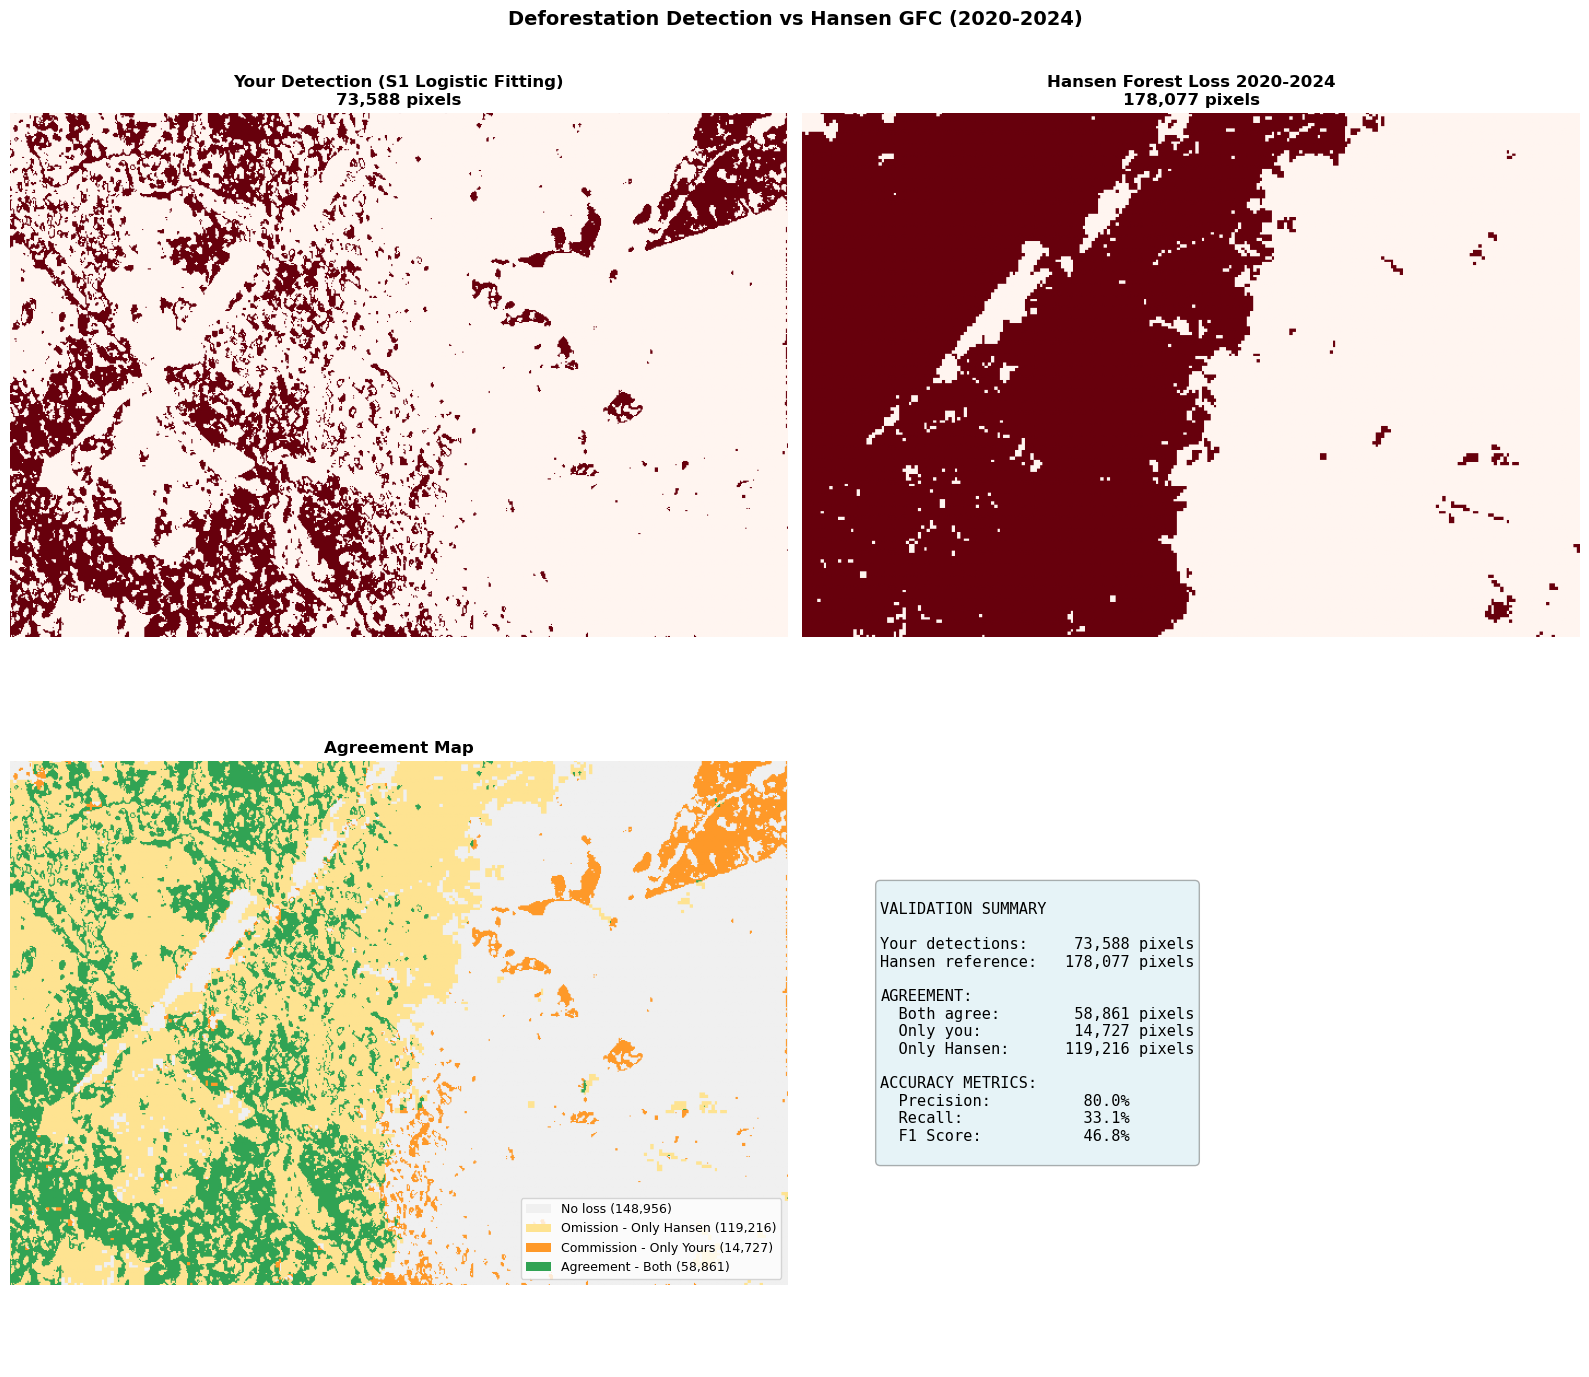

✓ Saved: /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/hansen_comparison.nc

DONE!


In [19]:
"""
HANSEN COMPARISON - SIMPLE VERSION
===================================
Compare logistic fitting results with Hansen forest loss
"""

import numpy as np
import xarray as xr
import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_bounds
from rasterio.crs import CRS
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ===================== LOAD YOUR DEFORESTATION RESULTS =====================
print("="*60)
print("LOADING DEFORESTATION RESULTS")
print("="*60)

logistic_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/logistic_fitting.nc"
ds = xr.open_dataset(logistic_file)

defor_mask = ds['defor_mask'].values
defor_years = ds['defor_years'].values

# Get extent
x_min, x_max = ds.x.min().item(), ds.x.max().item()
y_min, y_max = ds.y.min().item(), ds.y.max().item()
height, width = defor_mask.shape

print(f"Your deforestation mask: {defor_mask.shape}")
print(f"Extent: [{x_min:.6f}, {x_max:.6f}] x [{y_min:.6f}, {y_max:.6f}]")
print(f"Detected pixels: {defor_mask.sum():,}")

# ===================== LOAD & CROP HANSEN =====================
print("\n" + "="*60)
print("LOADING HANSEN DATA")
print("="*60)

hansen_path = "/home/georg/data/LEON_P6_forest-agri-change/Hansen/Hansen_GFC-2024-v1.12_lossyear_10N_030E.tif"

# Reproject Hansen to match S1 grid
hansen_data = np.zeros((height, width), dtype=np.uint8)

s1_crs = CRS.from_epsg(4326)
s1_transform = from_bounds(x_min, y_min, x_max, y_max, width, height)

with rasterio.open(hansen_path) as src:
    print(f"Hansen CRS: {src.crs}")
    print(f"Hansen shape: {src.shape}")
    
    # Reproject to S1 grid
    reproject(
        source=rasterio.band(src, 1),
        destination=hansen_data,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=s1_transform,
        dst_crs=s1_crs,
        resampling=Resampling.nearest
    )

# Filter Hansen to 2020-2024 (loss years 20-24)
hansen_2020_2024 = ((hansen_data >= 20) & (hansen_data <= 24)).astype(int)

print(f"✓ Hansen reprojected to S1 grid: {hansen_data.shape}")
print(f"✓ Hansen loss 2020-2024: {hansen_2020_2024.sum():,} pixels")

# ===================== CALCULATE AGREEMENT METRICS =====================
print("\n" + "="*60)
print("VALIDATION METRICS")
print("="*60)

# Convert to binary
your_defor = defor_mask.astype(int)
hansen_ref = hansen_2020_2024.astype(int)

# Confusion matrix
true_positive = np.sum((your_defor == 1) & (hansen_ref == 1))
false_positive = np.sum((your_defor == 1) & (hansen_ref == 0))
false_negative = np.sum((your_defor == 0) & (hansen_ref == 1))
true_negative = np.sum((your_defor == 0) & (hansen_ref == 0))

# Metrics
total_detected = true_positive + false_positive
total_reference = true_positive + false_negative

precision = (true_positive / total_detected * 100) if total_detected > 0 else 0
recall = (true_positive / total_reference * 100) if total_reference > 0 else 0
f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0

print(f"Your detections:     {your_defor.sum():,} pixels")
print(f"Hansen reference:    {hansen_ref.sum():,} pixels")
print(f"\nAgreement:")
print(f"  Both agree:        {true_positive:,} pixels")
print(f"  Only you:          {false_positive:,} pixels (commission)")
print(f"  Only Hansen:       {false_negative:,} pixels (omission)")
print(f"\nMetrics:")
print(f"  Precision:         {precision:.1f}% (your detections that are correct)")
print(f"  Recall:            {recall:.1f}% (Hansen detections you captured)")
print(f"  F1 Score:          {f1:.1f}% (overall agreement)")

# ===================== VISUALIZATION =====================
print("\nCreating comparison plots...")

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Your detection
axes[0, 0].imshow(your_defor, cmap='Reds', vmin=0, vmax=1)
axes[0, 0].set_title(f'Your Detection (S1 Logistic Fitting)\n{your_defor.sum():,} pixels', 
                     fontweight='bold', fontsize=12)
axes[0, 0].axis('off')

# 2. Hansen reference
axes[0, 1].imshow(hansen_ref, cmap='Reds', vmin=0, vmax=1)
axes[0, 1].set_title(f'Hansen Forest Loss 2020-2024\n{hansen_ref.sum():,} pixels', 
                     fontweight='bold', fontsize=12)
axes[0, 1].axis('off')

# 3. Agreement map
agreement = np.zeros_like(your_defor, dtype=int)
agreement[(your_defor == 0) & (hansen_ref == 0)] = 0  # No loss
agreement[(your_defor == 0) & (hansen_ref == 1)] = 1  # Omission (missed)
agreement[(your_defor == 1) & (hansen_ref == 0)] = 2  # Commission (false alarm)
agreement[(your_defor == 1) & (hansen_ref == 1)] = 3  # Correct detection

colors = ['#f0f0f0', '#fee391', '#fe9929', '#31a354']  # grey, yellow, orange, green
cmap = ListedColormap(colors)

axes[1, 0].imshow(agreement, cmap=cmap, vmin=0, vmax=3)
axes[1, 0].set_title('Agreement Map', fontweight='bold', fontsize=12)
axes[1, 0].axis('off')

legend_elements = [
    Patch(facecolor='#f0f0f0', label=f'No loss ({true_negative:,})'),
    Patch(facecolor='#fee391', label=f'Omission - Only Hansen ({false_negative:,})'),
    Patch(facecolor='#fe9929', label=f'Commission - Only Yours ({false_positive:,})'),
    Patch(facecolor='#31a354', label=f'Agreement - Both ({true_positive:,})')
]
axes[1, 0].legend(handles=legend_elements, loc='lower right', fontsize=9)

# 4. Metrics summary
axes[1, 1].axis('off')
metrics_text = f"""
VALIDATION SUMMARY

Your detections:    {your_defor.sum():>7,} pixels
Hansen reference:   {hansen_ref.sum():>7,} pixels

AGREEMENT:
  Both agree:       {true_positive:>7,} pixels
  Only you:         {false_positive:>7,} pixels
  Only Hansen:      {false_negative:>7,} pixels

ACCURACY METRICS:
  Precision:        {precision:>6.1f}%
  Recall:           {recall:>6.1f}%
  F1 Score:         {f1:>6.1f}%
"""

axes[1, 1].text(0.1, 0.5, metrics_text, 
                fontsize=11, 
                verticalalignment='center', 
                family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.suptitle('Deforestation Detection vs Hansen GFC (2020-2024)', 
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('hansen_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Saved: hansen_comparison.png")
plt.show()

# ===================== SAVE COMPARISON RESULTS =====================
output_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/hansen_comparison.nc"

ds_comp = xr.Dataset({
    'your_defor': (['y', 'x'], your_defor),
    'hansen_ref': (['y', 'x'], hansen_ref),
    'agreement': (['y', 'x'], agreement),
}, coords={'x': ds.x, 'y': ds.y})

ds_comp.attrs.update({
    'crs': 'EPSG:4326',
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'true_positive': int(true_positive),
    'false_positive': int(false_positive),
    'false_negative': int(false_negative),
})

ds_comp.to_netcdf(output_file)
print(f"✓ Saved: {output_file}")

print("\n" + "="*60)
print("DONE!")
print("="*60)

HANSEN COMPARISON - ALL THRESHOLDS
Extent: [30.926001, 30.989792] x [1.249092, 1.292398]

Your detections:
  Conservative: 88,435 pixels
  Moderate: 107,541 pixels
  Permissive: 117,118 pixels

Loading Hansen...
✓ Hansen 2020-2024: 178,077 pixels

VALIDATION METRICS FOR ALL THRESHOLDS

CONSERVATIVE:
  Your detections:   88,435 pixels
  Agreement (TP):    81,031 pixels
  Commission (FP):    7,404 pixels
  Omission (FN):     97,046 pixels
  Precision:          91.6%
  Recall:             45.5%
  F1 Score:           60.8%

MODERATE:
  Your detections:  107,541 pixels
  Agreement (TP):    98,805 pixels
  Commission (FP):    8,736 pixels
  Omission (FN):     79,272 pixels
  Precision:          91.9%
  Recall:             55.5%
  F1 Score:           69.2%

PERMISSIVE:
  Your detections:  117,118 pixels
  Agreement (TP):   107,446 pixels
  Commission (FP):    9,672 pixels
  Omission (FN):     70,631 pixels
  Precision:          91.7%
  Recall:             60.3%
  F1 Score:           72.8%

✓ 

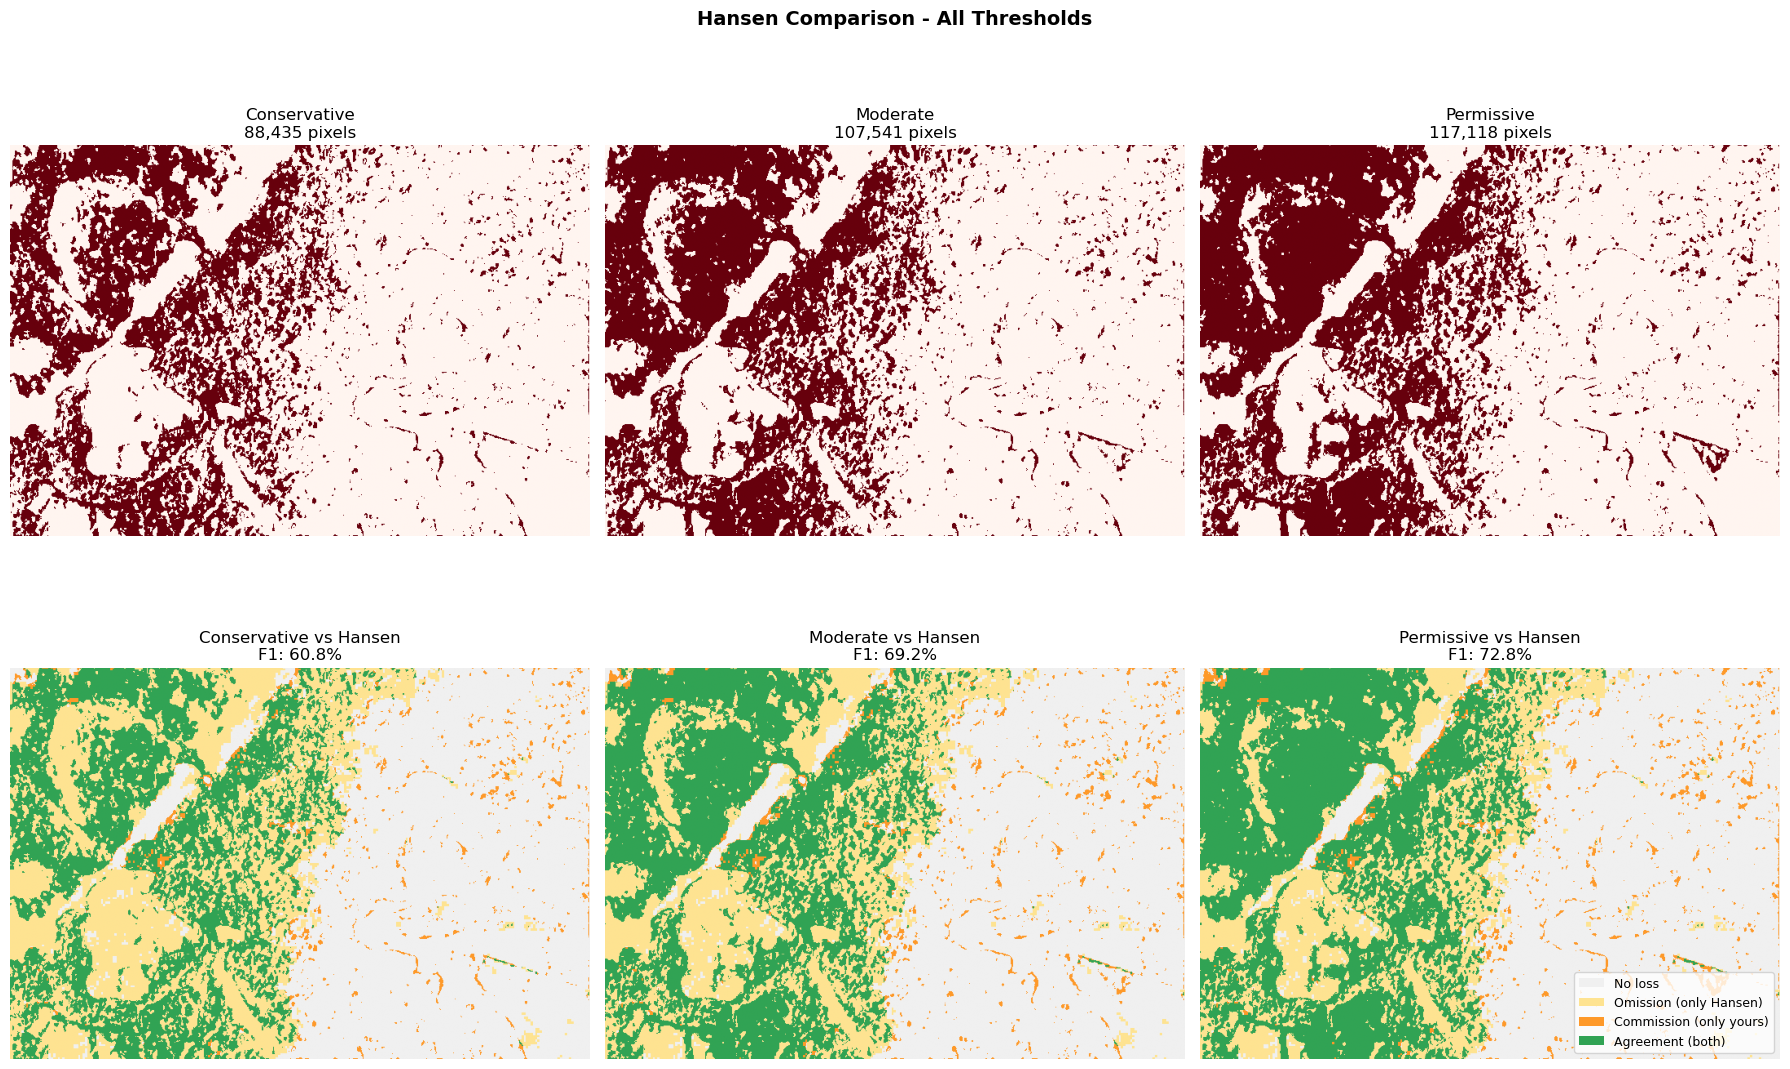

✓ Saved: hansen_metrics_comparison.png


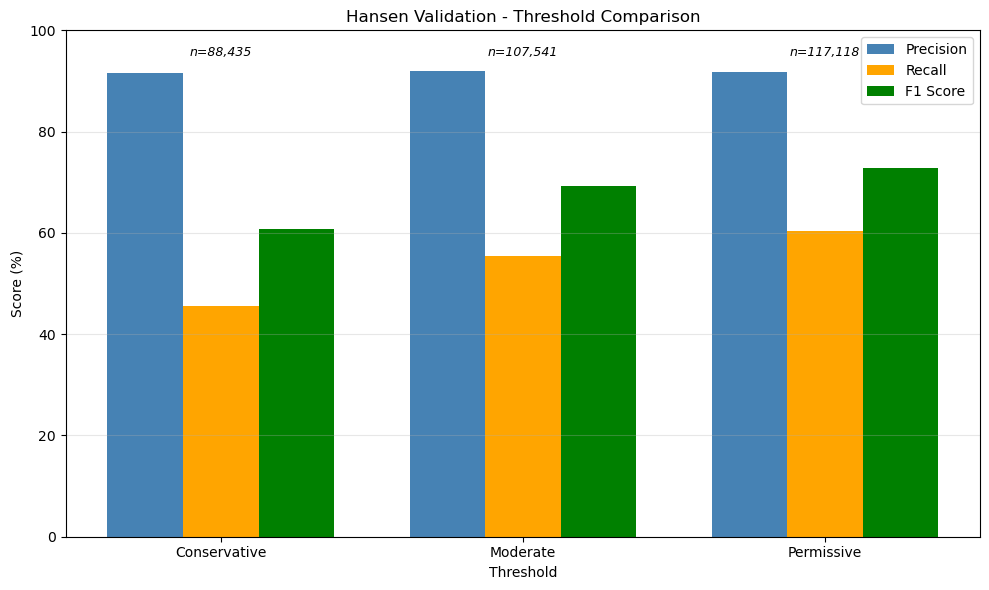


RECOMMENDATION
Best F1 score: PERMISSIVE (72.8%)
  Precision: 91.7%
  Recall: 60.3%


In [43]:
"""
HANSEN COMPARISON - COMPARE ALL THRESHOLDS
===========================================
"""

import numpy as np
import xarray as xr
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
from rasterio.crs import CRS
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ===================== LOAD RESULTS =====================
print("="*60)
print("HANSEN COMPARISON - ALL THRESHOLDS")
print("="*60)

logistic_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/logistic_fitting_f012.nc"
ds = xr.open_dataset(logistic_file)

# Load all three masks
masks = {
    'conservative': ds['defor_mask_conservative'].values,
    'moderate': ds['defor_mask'].values,  # This is the main one
    'permissive': ds['defor_mask_permissive'].values
}

x_min, x_max = ds.x.min().item(), ds.x.max().item()
y_min, y_max = ds.y.min().item(), ds.y.max().item()
height, width = masks['moderate'].shape

print(f"Extent: [{x_min:.6f}, {x_max:.6f}] x [{y_min:.6f}, {y_max:.6f}]")
print(f"\nYour detections:")
for name, mask in masks.items():
    print(f"  {name.capitalize()}: {mask.sum():,} pixels")

# ===================== LOAD HANSEN =====================
print("\nLoading Hansen...")

hansen_path = "/home/georg/data/LEON_P6_forest-agri-change/Hansen/Hansen_GFC-2024-v1.12_lossyear_10N_030E.tif"
hansen_data = np.zeros((height, width), dtype=np.uint8)

s1_crs = CRS.from_epsg(4326)
s1_transform = from_bounds(x_min, y_min, x_max, y_max, width, height)

with rasterio.open(hansen_path) as src:
    reproject(
        source=rasterio.band(src, 1),
        destination=hansen_data,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=s1_transform,
        dst_crs=s1_crs,
        resampling=Resampling.nearest
    )

hansen_ref = ((hansen_data >= 20) & (hansen_data <= 24)).astype(int)
print(f"✓ Hansen 2020-2024: {hansen_ref.sum():,} pixels")

# ===================== COMPARE ALL THRESHOLDS =====================
print("\n" + "="*60)
print("VALIDATION METRICS FOR ALL THRESHOLDS")
print("="*60)

results = {}

for name, your_defor in masks.items():
    your_defor = your_defor.astype(int)
    
    # Confusion matrix
    tp = np.sum((your_defor == 1) & (hansen_ref == 1))
    fp = np.sum((your_defor == 1) & (hansen_ref == 0))
    fn = np.sum((your_defor == 0) & (hansen_ref == 1))
    
    # Metrics
    precision = (tp / (tp + fp) * 100) if (tp + fp) > 0 else 0
    recall = (tp / (tp + fn) * 100) if (tp + fn) > 0 else 0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0
    
    results[name] = {
        'detected': your_defor.sum(),
        'tp': tp, 'fp': fp, 'fn': fn,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }
    
    print(f"\n{name.upper()}:")
    print(f"  Your detections:  {your_defor.sum():>7,} pixels")
    print(f"  Agreement (TP):   {tp:>7,} pixels")
    print(f"  Commission (FP):  {fp:>7,} pixels")
    print(f"  Omission (FN):    {fn:>7,} pixels")
    print(f"  Precision:        {precision:>6.1f}%")
    print(f"  Recall:           {recall:>6.1f}%")
    print(f"  F1 Score:         {f1:>6.1f}%")

# ===================== VISUALIZATION =====================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: Your detections
for idx, (name, mask) in enumerate(masks.items()):
    axes[0, idx].imshow(mask, cmap='Reds')
    axes[0, idx].set_title(f'{name.capitalize()}\n{mask.sum():,} pixels')
    axes[0, idx].axis('off')

# Row 2: Agreement maps
colors = ['#f0f0f0', '#fee391', '#fe9929', '#31a354']
cmap = ListedColormap(colors)

for idx, (name, mask) in enumerate(masks.items()):
    your_defor = mask.astype(int)
    
    agreement = np.zeros_like(your_defor)
    agreement[(your_defor == 0) & (hansen_ref == 0)] = 0
    agreement[(your_defor == 0) & (hansen_ref == 1)] = 1
    agreement[(your_defor == 1) & (hansen_ref == 0)] = 2
    agreement[(your_defor == 1) & (hansen_ref == 1)] = 3
    
    axes[1, idx].imshow(agreement, cmap=cmap, vmin=0, vmax=3)
    axes[1, idx].set_title(f'{name.capitalize()} vs Hansen\nF1: {results[name]["f1"]:.1f}%')
    axes[1, idx].axis('off')

# Legend on last subplot
legend_elements = [
    Patch(facecolor='#f0f0f0', label='No loss'),
    Patch(facecolor='#fee391', label='Omission (only Hansen)'),
    Patch(facecolor='#fe9929', label='Commission (only yours)'),
    Patch(facecolor='#31a354', label='Agreement (both)')
]
axes[1, 2].legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.suptitle('Hansen Comparison - All Thresholds', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('hansen_comparison_all_thresholds.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved: hansen_comparison_all_thresholds.png")
plt.show()

# ===================== METRICS SUMMARY PLOT =====================
fig, ax = plt.subplots(figsize=(10, 6))

threshold_names = list(results.keys())
precision_vals = [results[k]['precision'] for k in threshold_names]
recall_vals = [results[k]['recall'] for k in threshold_names]
f1_vals = [results[k]['f1'] for k in threshold_names]

x = np.arange(len(threshold_names))
width = 0.25

ax.bar(x - width, precision_vals, width, label='Precision', color='steelblue')
ax.bar(x, recall_vals, width, label='Recall', color='orange')
ax.bar(x + width, f1_vals, width, label='F1 Score', color='green')

ax.set_xlabel('Threshold')
ax.set_ylabel('Score (%)')
ax.set_title('Hansen Validation - Threshold Comparison')
ax.set_xticks(x)
ax.set_xticklabels([n.capitalize() for n in threshold_names])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 100)

for i, name in enumerate(threshold_names):
    ax.text(i, 95, f'n={results[name]["detected"]:,}', 
            ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('hansen_metrics_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Saved: hansen_metrics_comparison.png")
plt.show()

print("\n" + "="*60)
print("RECOMMENDATION")
print("="*60)

# Find best F1
best_threshold = max(results.keys(), key=lambda k: results[k]['f1'])
print(f"Best F1 score: {best_threshold.upper()} ({results[best_threshold]['f1']:.1f}%)")
print(f"  Precision: {results[best_threshold]['precision']:.1f}%")
print(f"  Recall: {results[best_threshold]['recall']:.1f}%")